# Denoising Diffusion Probabilistic Models (DDPM) with miniai

---

**What is this notebook about?**

This notebook introduces **Diffusion Models**, specifically the **Denoising Diffusion Probabilistic Model (DDPM)**. Diffusion models are a type of generative model - meaning they can **create new data** (in our case, images) that look similar to the training data.

Think of it like this: imagine you have a photo and you slowly add more and more static noise to it until it becomes completely unrecognizable (like TV static). A diffusion model learns to **reverse this process** - it learns to take pure noise and gradually remove the noise until a clear image emerges!

---

**Why are diffusion models important?**

Diffusion models are the foundation of many modern AI image generators like:
- Stable Diffusion
- DALL-E 2/3
- Midjourney

Understanding DDPMs is the first step to understanding how these powerful tools work!

---

**A brief history:**

- **2015**: Diffusion models were first introduced but were complicated and hard to train
- **2020**: The landmark paper "Denoising Diffusion Probabilistic Models" (DDPM) simplified the training process dramatically
- **2022+**: Diffusion models became the state-of-the-art for image generation

We'll implement the 2020 DDPM approach in this notebook.

---

## The Core Idea of Diffusion Models

Before we dive into code, let's understand the key concept:

**The Forward Process (Adding Noise):**
```
Clean Image → Add a little noise → Add more noise → ... → Pure Random Noise
   (x₀)           (x₁)              (x₂)                      (x_T)
```

We take a clean image and gradually add Gaussian noise over many steps (typically 1000 steps). At the end, the image is indistinguishable from pure random noise.

**The Reverse Process (Removing Noise) - What we train:**
```
Pure Random Noise → Remove some noise → Remove more noise → ... → Clean Image
     (x_T)              (x_{T-1})          (x_{T-2})                  (x₀)
```

We train a neural network to predict and remove the noise at each step. Once trained, we can start with pure random noise and generate new images!

---

## 🎮 Interactive Visualizations — Setup

This notebook embeds **8 interactive visualizations** (2D + 3D) that let you *play with* every core DDPM idea: the forward/reverse processes, the variance schedule, the closed-form noising jump, the U-Net, the training step, the sampling loop, and the callback dispatch machinery.

Run the cell below **once**. Each "🎮 Interactive" cell then loads a standalone HTML file from the published copy on GitHub Pages, in an isolated `<iframe>` (its CSS/JS can't leak into the notebook). Each is shown **full width** and **auto-fits its content height** — no dead space below.

In [ ]:
# ============================================================================
# INTERACTIVE VISUALIZATIONS -- setup (run this cell ONCE).
# Each "🎮 Interactive" cell below loads a standalone HTML file from the
# published copy on GitHub Pages, in an isolated <iframe> (its CSS/JS can't leak
# into the notebook). It is shown FULL WIDTH and auto-fits its content height.
# No local files needed -- the visualizations are read from GitHub.
# ============================================================================
from IPython.display import HTML

def show_viz(path, height="600px"):
    """Embed an interactive visualization full width; it auto-fits its height.
    `path` may be a bare 'interactive_viz/<file>.html' (resolved to the GitHub
    Pages copy) or a full https URL."""
    base = "https://shammun.github.io/shammunul-fastai-notes/notebooks/"
    if not path.startswith("http"):
        path = base + path
    return HTML(
        f'<iframe src="{path}" loading="lazy" allowfullscreen '
        f'style="width:100%;height:{height};border:1px solid #dde5f2;border-radius:12px;'
        f'box-shadow:0 8px 24px rgba(123,92,214,.12);background:#fff;"></iframe>'
        '<script>addEventListener("message",function(e){'
        'if(e.data&&e.data.type==="ce-frame-height"&&e.data.height>50){'
        'var fs=document.querySelectorAll("iframe");for(var i=0;i<fs.length;i++){'
        'if(fs[i].contentWindow===e.source){fs[i].style.height=e.data.height+"px";break;}}}});</script>'
    )

### 🎮 Interactive: The Big Picture — Forward vs Reverse

Before any code: build the mental model. Watch the **forward process** grind a sneaker into pure Gaussian noise over 1000 steps, then flip direction and watch the **learned reverse process** rebuild it. Drag the timeline, click any thumbnail to jump to that timestep, and watch the signal/noise mixing bars track √ᾱ_t and √(1−ᾱ_t) live.

In [ ]:
show_viz("interactive_viz/ddpm_big_picture.html", height="760px")

### 🎮 Interactive: Diffusion in 3D — A Whole Distribution Melting

The image-strip view shows *one* image getting noisier; this 3D view shows what happens to the **entire dataset**. Every dot is a data point; the forward process diffuses the structured swiss-roll into a featureless N(0, I) ball — the one distribution we can trivially sample from. Drag to orbit, scroll to zoom, and run it in both directions.

In [ ]:
show_viz("interactive_viz/diffusion_3d_trajectory.html", height="720px")

## Section 1: Imports

First, we need to import all the libraries and modules we'll use. Let's go through each import and understand what it's for.

In [ ]:
# ============================================================================
# STANDARD PYTHON LIBRARIES
# ============================================================================

import pickle, gzip, math, os, time, shutil, torch, random, logging
# - pickle: For saving/loading Python objects to files
# - gzip: For working with compressed files
# - math: Mathematical functions (sqrt, sin, cos, etc.)
# - os: Operating system interface (file paths, directories)
# - time: For timing operations
# - shutil: High-level file operations (copy, move files)
# - torch: PyTorch - the main deep learning library we use
# - random: Random number generation
# - logging: For displaying log messages

import fastcore.all as fc  # fastcore: Utility library with helpful Python extensions
import matplotlib as mpl   # matplotlib: Main plotting library
import numpy as np         # numpy: Numerical computing library for arrays
import matplotlib.pyplot as plt  # pyplot: MATLAB-like plotting interface

from collections.abc import Mapping  # For type checking dictionary-like objects
from pathlib import Path             # Modern way to handle file paths
from operator import attrgetter, itemgetter  # Functions to get attributes/items
from functools import partial        # Create partial functions with some args pre-filled
from copy import copy                # Create shallow copies of objects
from contextlib import contextmanager  # For creating context managers (with statements)

from fastcore.foundation import L  # L is an enhanced list class from fastcore

# ============================================================================
# PYTORCH AND TORCHVISION IMPORTS
# ============================================================================

import torchvision.transforms.functional as TF  # Image transformations (resize, rotate, etc.)
import torch.nn.functional as F                  # Neural network functions (activation funcs, etc.)

from torch import tensor, nn, optim  
# - tensor: Create PyTorch tensors (like numpy arrays but can run on GPU)
# - nn: Neural network module (layers, loss functions, etc.)
# - optim: Optimization algorithms (SGD, Adam, etc.)

from torch.utils.data import DataLoader, default_collate
# - DataLoader: Loads data in batches for training
# - default_collate: Combines individual samples into a batch

from torch.nn import init  # Weight initialization methods
from torch.optim import lr_scheduler  # Learning rate schedulers
from torcheval.metrics import MulticlassAccuracy  # Accuracy metric
from datasets import load_dataset, load_dataset_builder  # HuggingFace datasets library

# ============================================================================
# MINIAI IMPORTS (Our custom training library from previous notebooks)
# ============================================================================

from miniai.datasets import *    # Dataset utilities
from miniai.conv import *        # Convolutional layer utilities
from miniai.learner import *     # The Learner class for training
from miniai.activations import * # Activation functions and hooks
from miniai.init import *        # Initialization utilities
from miniai.sgd import *         # SGD and optimization utilities
from miniai.resnet import *      # ResNet architecture utilities
from miniai.augment import *     # Data augmentation utilities

**What does the code above do?**

This cell imports all the libraries we need:
1. **Standard Python libraries** - Basic functionality like file handling, math, timing
2. **PyTorch and related** - The deep learning framework we use to build and train neural networks
3. **miniai** - Our custom training library built in previous notebooks of this course

The `*` in imports like `from miniai.datasets import *` means "import everything from this module".

In [ ]:
# Set the default colormap for matplotlib to grayscale
# This is because our Fashion MNIST images are grayscale (black and white)
mpl.rcParams['image.cmap'] = 'gray'

# Disable warning messages from the logging system
# This keeps our output clean (warnings from libraries like HuggingFace can be noisy)
logging.disable(logging.WARNING)

**What does the code above do?**

1. `mpl.rcParams['image.cmap'] = 'gray'`: Sets matplotlib to display images in grayscale by default. Since Fashion MNIST images are black and white, this ensures they display correctly.

2. `logging.disable(logging.WARNING)`: Suppresses warning messages that libraries might print. This keeps our notebook output clean and focused on what matters.

---

## Section 2: Loading the Dataset

We'll use the **Fashion MNIST** dataset, which contains 70,000 grayscale images of clothing items (28x28 pixels each).

**What is Fashion MNIST?**

It's a dataset of Zalando's article images with 10 categories:
- 0: T-shirt/top
- 1: Trouser
- 2: Pullover
- 3: Dress
- 4: Coat
- 5: Sandal
- 6: Shirt
- 7: Sneaker
- 8: Bag
- 9: Ankle boot

We'll load it from the HuggingFace Hub (a repository for datasets and models).

In [ ]:
# Define which keys in the dataset contain the image and label
x, y = 'image', 'label'
# x = 'image' means the images are stored under the key 'image'
# y = 'label' means the labels are stored under the key 'label'

# Name of the dataset to load from HuggingFace
name = "zalando-datasets/fashion_mnist"

# Load the dataset from HuggingFace Hub
# This downloads the dataset and creates a DatasetDict object
dsd = load_dataset(name)

**What does the code above do?**

1. **`x, y = 'image', 'label'`**: This is Python's tuple unpacking. It's equivalent to:
   ```python
   x = 'image'
   y = 'label'
   ```
   These strings tell us which keys in the dataset dictionary contain our images and labels.

2. **`name = "fashion_mnist"`**: The name of the dataset on HuggingFace Hub.

3. **`dsd = load_dataset(name)`**: Downloads and loads the Fashion MNIST dataset. The result `dsd` is a `DatasetDict` containing both training and test splits.

**Why Fashion MNIST?**

It's a good starting dataset because:
- Images are small (28x28 pixels) so training is fast
- It's more interesting than regular MNIST (handwritten digits)
- The patterns (clothing) are more complex, testing our model's capabilities

### Resizing Images

The original images are 28x28 pixels. We'll resize them to 32x32 pixels.

**Why 32x32?**

The U-Net architecture we'll use works best with images whose dimensions are powers of 2 (like 32, 64, 128, etc.). This is because U-Nets repeatedly halve the image size (via downsampling) and then double it back (via upsampling). With 32x32:
- 32 → 16 → 8 → 4 → 8 → 16 → 32

With 28x28, we'd have awkward fractional dimensions:
- 28 → 14 → 7 → 3.5 (problem!)

In [ ]:
@inplace  # This decorator modifies the input 'b' in place (doesn't return a new object)
def transformi(b): 
    """
    Transform function applied to each batch of data.
    Converts images to tensors and resizes them to 32x32.
    
    Parameters:
    -----------
    b : dict
        A batch dictionary containing 'image' and 'label' keys
    """
    # For each image 'o' in the batch:
    # 1. TF.to_tensor(o): Convert PIL Image to PyTorch tensor
    #    - Also scales pixel values from 0-255 to 0.0-1.0
    #    - Changes shape from (H, W) to (1, H, W) for grayscale
    # 2. TF.resize(..., (32,32)): Resize the tensor to 32x32 pixels
    b[x] = [TF.resize(TF.to_tensor(o), (32, 32)) for o in b[x]]

**What does the code above do?**

This defines a transformation function that will be applied to every batch of data:

1. **`@inplace`**: A decorator that tells Python this function modifies its input directly rather than returning a new object.

2. **`TF.to_tensor(o)`**: Converts each image from a PIL Image object to a PyTorch tensor. This also:
   - Converts pixel values from integers (0-255) to floats (0.0-1.0)
   - Adds a channel dimension, so shape becomes (1, 28, 28) for grayscale

3. **`TF.resize(..., (32, 32))`**: Resizes the image from 28x28 to 32x32 pixels.

4. **List comprehension `[... for o in b[x]]`**: Applies these transformations to every image in the batch.

---

**Example of what `to_tensor` does:**

```python
# Before: PIL Image with shape (28, 28), pixel values 0-255
# After: PyTorch tensor with shape (1, 28, 28), values 0.0-1.0
```

### Creating DataLoaders

Now we'll create DataLoaders which load our data in batches during training.

**What is a batch?**

Instead of training on one image at a time (slow and unstable) or all images at once (uses too much memory), we train on small groups called "batches". A batch size of 128 means we process 128 images at a time.

**Important note about labels:**

While Fashion MNIST has labels (T-shirt, Trouser, etc.), we won't use them! We're doing **unconditional image generation** - our model will learn to generate clothing images without being told what type to generate.

In [11]:
# Set random seed for reproducibility
# This ensures we get the same "random" results every time we run the code
set_seed(42)

# Batch size: how many images to process at once
bs = 128

# Apply our transformation function to the dataset
# with_transform() creates a new dataset that applies transformi to each batch
tds = dsd.with_transform(transformi)

# Create DataLoaders from the transformed dataset
# - bs: batch size (128 images per batch)
# - num_workers=8: use 8 parallel processes to load data faster
dls = DataLoaders.from_dd(tds, bs, num_workers=8)

# Get the training dataloader
dt = dls.train

# Get one batch of data to verify everything works
# next(iter(dt)) gets the first batch from the dataloader
xb, yb = next(iter(dt))

# Print the shape of images and first 10 labels to verify
# xb.shape should be (128, 1, 32, 32): 128 images, 1 channel (grayscale), 32x32 pixels
xb.shape, yb[:10]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


(torch.Size([128, 1, 32, 32]), tensor([5, 7, 4, 7, 3, 8, 9, 5, 3, 1]))

**What does the code above do? (Line by line)**

1. **`set_seed(42)`**: Sets the random seed to 42. This makes our "random" operations reproducible - running the code multiple times gives the same results. The number 42 is arbitrary (it's a reference to "The Hitchhiker's Guide to the Galaxy").

2. **`bs = 128`**: Sets our batch size to 128 images.

3. **`tds = dsd.with_transform(transformi)`**: Creates a transformed version of the dataset that applies our `transformi` function whenever data is loaded.

4. **`dls = DataLoaders.from_dd(tds, bs, num_workers=8)`**: Creates DataLoaders:
   - `from_dd`: Creates from a DatasetDict (which has train and test splits)
   - `bs`: Batch size
   - `num_workers=8`: Number of parallel processes for loading data. More workers = faster loading, but uses more CPU/memory.

5. **`dt = dls.train`**: Gets just the training dataloader.

6. **`xb, yb = next(iter(dt))`**: Gets one batch:
   - `iter(dt)`: Creates an iterator from the dataloader
   - `next(...)`: Gets the next (first) item from the iterator
   - The result is unpacked into `xb` (images) and `yb` (labels)

7. **`xb.shape, yb[:10]`**: Displays the shape of our image batch and the first 10 labels.

**Expected output:**
- `xb.shape`: `torch.Size([128, 1, 32, 32])` meaning:
  - 128 images in the batch
  - 1 color channel (grayscale)
  - 32x32 pixels each
- `yb[:10]`: The first 10 class labels (numbers 0-9)

---

## Section 3: Creating the Model

For DDPM, we need a neural network that can:
1. Take in a noisy image
2. Take in a timestep (how noisy is the image?)
3. Output a prediction of the noise in the image

The standard architecture for this is a **U-Net**.

### What is a U-Net?

A U-Net is a type of neural network architecture shaped like the letter "U":

<img src="https://huggingface.co/blog/assets/78_annotated-diffusion/unet_architecture.jpg" width="700">

**How it works:**

1. **Encoder (left side, going down)**: The image gets progressively smaller but deeper (more channels). This captures "what" is in the image at different scales.

2. **Bottleneck (bottom)**: The smallest representation of the image.

3. **Decoder (right side, going up)**: The image is expanded back to original size, using information from the encoder via "skip connections" (the horizontal arrows).

**Why U-Net for diffusion?**

- It outputs an image the same size as the input (important for predicting noise)
- Skip connections preserve fine details
- It can process images at multiple scales

### DDPM U-Net

The DDPM paper uses a modified U-Net with additional features:
- **Timestep embedding**: The network knows which timestep it's at
- **Attention layers**: Helps the model focus on relevant parts of the image
- **Residual blocks**: Makes training more stable

We'll cover these details in future lessons. For now, we'll use a pre-built U-Net from the `diffusers` library (by HuggingFace).

In [ ]:
# Import the UNet2DModel from diffusers library
# diffusers is HuggingFace's library for diffusion models
from diffusers import UNet2DModel

In [ ]:
# Create our U-Net model
model = UNet2DModel(
    in_channels=1,    # Input has 1 channel (grayscale images)
    out_channels=1,   # Output has 1 channel (predicting noise for grayscale)
    block_out_channels=(32, 64, 128, 128)  # Number of channels at each level of the U-Net
)

**What does the code above do?**

We create a U-Net model with these parameters:

1. **`in_channels=1`**: The input images have 1 color channel (grayscale). For RGB images, this would be 3.

2. **`out_channels=1`**: The output also has 1 channel. The model outputs a noise prediction that has the same shape as the input image.

3. **`block_out_channels=(32, 64, 128, 128)`**: This defines the "width" of the network at each level:
   - Level 1: 32 channels (input resolution)
   - Level 2: 64 channels (half resolution)
   - Level 3: 128 channels (quarter resolution)
   - Level 4: 128 channels (eighth resolution, the bottleneck)
   
   More channels = more capacity to learn complex patterns, but also more computation.

**Visual representation of the model dimensions:**
```
Input: (batch, 1, 32, 32)
   ↓
Level 1: (batch, 32, 32, 32) → (batch, 32, 16, 16)
   ↓
Level 2: (batch, 64, 16, 16) → (batch, 64, 8, 8)
   ↓
Level 3: (batch, 128, 8, 8) → (batch, 128, 4, 4)
   ↓
Bottleneck: (batch, 128, 4, 4)
   ↓
(Then back up with skip connections)
   ↓
Output: (batch, 1, 32, 32)
```

### 🎮 Interactive: The DDPM U-Net, Exploded in 3D

The exact model built above — `UNet2DModel(in_channels=1, out_channels=1, block_out_channels=(32, 64, 128, 128))` — rendered as a 3D exploded diagram. Box height = channels, box width = spatial size. **Click any block** to see its tensor shapes and its job; toggle the skip connections and the timestep-embedding injection to see why both are essential.

In [ ]:
show_viz("interactive_viz/unet_ddpm_3d.html", height="700px")

---

## Section 4: Training with a Callback

Now we get to the heart of DDPM! We'll implement the training and sampling logic.

**What is a Callback?**

A callback is a piece of code that "hooks into" the training loop at specific points. Instead of modifying the main training code, we can add functionality via callbacks. This keeps the main training loop clean and makes it easy to add/remove features.

For DDPM, our callback will:
1. **Before each batch**: Add noise to images (the forward diffusion process)
2. **After training**: Sample new images (the reverse diffusion process)

### The DDPM Training Process

Let's understand the math before looking at the code.

**Key Variables:**

| Symbol | Name | Meaning |
|--------|------|--------|
| x₀ | Original image | The clean image from our dataset |
| xₜ | Noisy image | The image after adding noise for t steps |
| ε | Epsilon/Noise | Random Gaussian noise we add |
| t | Timestep | Which step in the noising process (0 to T) |
| T | Total steps | Usually 1000 in DDPM |
| β | Beta | Variance of noise at each step |
| α | Alpha | 1 - β (how much of the original image remains) |
| ᾱ | Alpha bar | Cumulative product of α (total signal remaining) |

**The Forward Process (Adding Noise):**

Instead of adding noise step by step, DDPM has a clever formula to jump directly to any timestep t:

```
xₜ = √(ᾱₜ) * x₀ + √(1-ᾱₜ) * ε
```

Where:
- `√(ᾱₜ) * x₀` is the "signal" (scaled original image)
- `√(1-ᾱₜ) * ε` is the "noise" (scaled random noise)

As t increases, ᾱₜ gets smaller, so we have less signal and more noise.

**Training Objective:**

Given a noisy image xₜ and timestep t, the model learns to predict ε (the noise that was added).

Loss = MSE(predicted_noise, actual_noise)

### The Variance Schedule

The variance schedule defines how much noise to add at each timestep.

**DDPM uses a linear schedule:**
- β starts small (β_min = 0.0001) and increases linearly to β_max (0.02)
- Early timesteps: small noise added
- Later timesteps: more noise added

```
β₁ = 0.0001, β₂ = 0.0001 + Δ, β₃ = 0.0001 + 2Δ, ..., β_T = 0.02
```

**Why this matters:**

- If β is too small: Takes forever to reach pure noise
- If β is too large: Jumps too quickly to noise, hard to learn to reverse
- The linear schedule in DDPM works well for 1000 steps

### 🎮 Interactive: The Variance Schedule Lab

The four tensors from `DDPMCB.__init__` (β, α, ᾱ, σ) plotted live. **Hover** to read exact values at any t (including the two coefficients √ᾱ_t and √(1−ᾱ_t) that the closed form uses), toggle curves on/off, and **drag β_min / β_max / n_steps** to see how the schedule reshapes — and why the paper's defaults are a sweet spot.

In [ ]:
show_viz("interactive_viz/variance_schedule_lab.html", height="720px")

In [ ]:
class DDPMCB(TrainCB):
    """
    Denoising Diffusion Probabilistic Model Callback.
    
    This callback handles:
    1. Setting up the noise schedule (β, α, ᾱ, σ)
    2. Adding noise to images during training (forward process)
    3. Sampling new images after training (reverse process)
    """
    
    # order determines when this callback runs relative to others
    # We need it to run AFTER DeviceCB (which moves data to GPU)
    order = DeviceCB.order + 1
    
    def __init__(self, n_steps, beta_min, beta_max):
        """
        Initialize the DDPM callback.
        
        Parameters:
        -----------
        n_steps : int
            Number of diffusion timesteps (typically 1000)
        beta_min : float
            Minimum variance (at t=0), typically 0.0001
        beta_max : float
            Maximum variance (at t=T), typically 0.02
        """
        super().__init__()  # Call parent class constructor
        
        # Store the parameters
        self.n_steps = n_steps        # Total number of timesteps (T)
        self.βmin = beta_min          # Minimum beta value
        self.βmax = beta_max          # Maximum beta value
        
        # ================================================================
        # VARIANCE SCHEDULE SETUP
        # ================================================================
        
        # β (beta): Variance schedule - linearly increases from βmin to βmax
        # torch.linspace creates n_steps evenly spaced values from βmin to βmax
        # Shape: (n_steps,) = (1000,)
        self.β = torch.linspace(self.βmin, self.βmax, self.n_steps)
        
        # α (alpha): How much of the signal (image) to keep at each step
        # α = 1 - β, so as β increases, α decreases
        # Shape: (n_steps,) = (1000,)
        self.α = 1. - self.β
        
        # ᾱ (alpha bar): Cumulative product of α
        # ᾱ_t = α_1 * α_2 * ... * α_t
        # This tells us the TOTAL signal remaining after t steps
        # torch.cumprod computes cumulative products
        # Example: cumprod([2, 3, 4]) = [2, 6, 24]
        # Shape: (n_steps,) = (1000,)
        self.ᾱ = torch.cumprod(self.α, dim=0)
        
        # σ (sigma): Standard deviation of noise to add during sampling
        # σ = √β
        # Shape: (n_steps,) = (1000,)
        self.σ = self.β.sqrt()

    def predict(self, learn):
        """
        How to get predictions from the model.
        
        The model takes (noisy_image, timestep) and outputs a prediction.
        The .sample attribute extracts the actual tensor from the model output.
        
        Parameters:
        -----------
        learn : Learner
            The learner object containing model and batch data
        """
        # learn.batch[0] is the tuple (noisy_image, timestep) because learn.batch is ((xt, t), ε) and 
        # is defined inside before_batch method below
        # *learn.batch[0] unpacks it as two separate arguments
        # .sample extracts the output tensor from the model's output object -- this sample method is defined 
        # in the diffusers library in HuggingFace
        learn.preds = learn.model(*learn.batch[0]).sample
    
    def before_batch(self, learn):
        """
        Called before each training batch.
        
        This is where we implement the FORWARD DIFFUSION PROCESS:
        1. Get the clean images
        2. Generate random noise
        3. Pick random timesteps
        4. Create noisy images using the formula: xₜ = √(ᾱₜ)*x₀ + √(1-ᾱₜ)*ε
        5. Set up the batch for training
        
        Parameters:
        -----------
        learn : Learner
            The learner object containing the current batch
        """
        # Get the device (CPU or GPU) where our data is
        device = learn.batch[0].device
        
        # ================================================================
        # STEP 1: Generate random noise (ε)
        # ================================================================
        # torch.randn creates random numbers from a standard normal distribution
        # (mean=0, std=1, i.e., Gaussian noise)
        # Shape: same as input images (batch_size, 1, 32, 32)
        ε = torch.randn(learn.batch[0].shape, device=device) # the actual noise
        # the actual noise we are adding and this is also the target, we try to predict the noise in the image
        
        # ================================================================
        # STEP 2: Get the original clean images (x₀)
        # ================================================================
        x0 = learn.batch[0]  # Shape: (batch_size, 1, 32, 32)
        # learn.batch = (images, labels)
        # So learn.batch[0] gives us the batch of images. We call this batch x0
        
        # Move ᾱ to the same device as our data (important for GPU training)
        self.ᾱ = self.ᾱ.to(device)
        
        # Get batch size
        n = x0.shape[0]  # Number of images in this batch
        
        # ================================================================
        # STEP 3: Select random timesteps for each image
        # ================================================================
        # Each image in the batch gets a different random timestep
        # torch.randint(low, high, size) generates random integers in [low, high)
        # Shape: (batch_size,) e.g., tensor([42, 731, 156, ...])
        t = torch.randint(0, self.n_steps, (n,), device=device, dtype=torch.long)
        # Each image in the batch gets its own independently sampled timestep.

        # t = torch.randint(0, 1000, (4,))
        # tensor([42, 731, 156, 908])
        #          ↑    ↑    ↑    ↑
        #        img0 img1 img2 img3
        #        gets gets gets gets
        #        t=42 t=731 t=156 t=908
        
        # ================================================================
        # STEP 4: Get ᾱ values for the selected timesteps
        # ================================================================
        # Index into ᾱ using our random timesteps
        # Then reshape to (batch_size, 1, 1, 1) for broadcasting
        # This allows element-wise multiplication with images of shape (batch_size, 1, 32, 32)
        ᾱ_t = self.ᾱ[t].reshape(-1, 1, 1, 1).to(device)
        # Shape: (batch_size, 1, 1, 1)
        
        # ================================================================
        # STEP 5: Create noisy images using the forward diffusion formula
        # ================================================================
        # Formula: xₜ = √(ᾱₜ) * x₀ + √(1-ᾱₜ) * ε
        # - ᾱ_t.sqrt() * x0: The "signal" part (scaled original image)
        # - (1-ᾱ_t).sqrt() * ε: The "noise" part (scaled random noise)
        xt = ᾱ_t.sqrt() * x0 + (1 - ᾱ_t).sqrt() * ε
        # Shape: (batch_size, 1, 32, 32)
        
        # ================================================================
        # STEP 6: Set up the batch for training
        # ================================================================
        # Model input: (noisy_image, timestep)
        # Target (ground truth): the noise ε that was added
        # The model will learn to predict ε from xt and t
        learn.batch = ((xt, t), ε)
        # so our target is learn.batch[1] which is ε
    
    @torch.no_grad()  # Disable gradient computation (we don't need it for sampling)
    def sample(self, model, sz):
        """
        Generate new images using the REVERSE DIFFUSION PROCESS.
        
        Starting from pure random noise, we iteratively denoise to get images.
        
        Parameters:
        -----------
        model : nn.Module
            The trained U-Net model
        sz : tuple
            Shape of images to generate, e.g., (16, 1, 32, 32) for 16 images

            sz = (16, 1, 32, 32)
            #     ↑   ↑   ↑   ↑
            #     |   |   |   └── Width: 32 pixels
            #     |   |   └────── Height: 32 pixels
            #     |   └────────── Channels: 1 (grayscale)
            #     └────────────── Batch size: 16 images to generate
            
        Returns:
        --------
        preds : list
            List of tensors, one for each timestep, showing the denoising process
        """
        # Get the device from the model's parameters
        device = next(model.parameters()).device 
        # model.parameters() returns an iterator over the model's parameters
        # next(model.parameters()) returns the first parameter of the model
        # .device returns the device (CPU or GPU) where the parameter is stored
        
        # ================================================================
        # STEP 1: Start with pure random noise (x_T)
        # ================================================================
        x_t = torch.randn(sz, device=device) # So based on the values of this, we will generate different images
        # So, every time we have different random noise, we will generate different images
        # So there will be no control over what type of images we generate as it all depends on the random noise we start with
        
        # List to store intermediate results for visualization
        preds = []
        
        # ================================================================
        # STEP 2: Iterate backwards through timesteps (T-1 to 0)
        # ================================================================
        # reversed(range(n)) goes from n-1 down to 0
        for t in reversed(range(self.n_steps)):
            
            # Create a batch of the same timestep for all images
            # Shape: (batch_size,) all filled with value t
            t_batch = torch.full((x_t.shape[0],), t, device=device, dtype=torch.long)
            
            # Add noise z for all steps except the final one (t=0)
            # At t=0, we don't add noise (z=0)
            z = (torch.randn(x_t.shape) if t > 0 else torch.zeros(x_t.shape)).to(device)
            
            # Get ᾱ for the previous timestep (t-1)
            # For t=0, we use 1 (meaning the original image has full signal)
            ᾱ_t1 = self.ᾱ[t-1] if t > 0 else torch.tensor(1)
            
            # Cumulative noise variance at timestep t
            b̄_t = 1 - self.ᾱ[t]
            
            # Cumulative noise variance at timestep t-1
            b̄_t1 = 1 - ᾱ_t1
            
            # ================================================================
            # STEP 3: Get noise prediction from the model
            # ================================================================
            noise_pred = learn.model(x_t, t_batch).sample # call the model on inputs or current noisy image x_t and timestep t_batch
            # Calls Unet2DModel
            """
            
            from diffusers import UNet2DModel

            # Create the U-Net model
            model = UNet2DModel(
            in_channels=1,           # Grayscale images (1 channel)
            out_channels=1,          # Output same size as input
            block_out_channels=(32, 64, 128),  # Channel sizes at each level
            # ... other parameters
            )
            # Then this model is passed to the Learner:
            learn = Learner(dls, model, ...)
            """


            # ================================================================
            # STEP 4: Estimate the clean image (x₀) from current noisy image
            # ================================================================
            # Rearranging the forward formula: x₀ = (xₜ - √(1-ᾱₜ)*ε) / √(ᾱₜ)
            # We use our noise prediction in place of the true ε
            # .clamp(-1, 1) keeps values in valid range
            x_0_hat = ((x_t - b̄_t.sqrt() * noise_pred) / self.ᾱ[t].sqrt()).clamp(-1, 1)
            
            # ================================================================
            # STEP 5: Calculate coefficients for the sampling formula
            # ================================================================
            # These coefficients come from the DDPM paper's posterior distribution
            x0_coeff = ᾱ_t1.sqrt() * (1 - self.α[t]) / b̄_t
            xt_coeff = self.α[t].sqrt() * b̄_t1 / b̄_t
            
            # ================================================================
            # STEP 6: Compute x_{t-1} (one step denoised)
            # ================================================================
            # x_{t-1} = x0_coeff * x₀_hat + xt_coeff * xₜ + σₜ * z
            x_t = x_0_hat * x0_coeff + x_t * xt_coeff + self.σ[t] * z
            
            # Store the current state for visualization
            preds.append(x_t.cpu()) # the last value of the preds gives us the final generated image
            # preds[-1]  # Final generated images (all 16 of them) where 16 is the batch size
            # So every 16 images generated is completely random and all the new images's label or type depend 
            # on from what random noise it started generating from

        return preds

## Why `learn.batch[0]` Means Different Things in `before_batch` vs `predict`

> This note explains a genuine inconsistency in the comments of the `DDPMCB` class, and clarifies exactly what `learn.batch` contains at each point in the training loop.

---

### The Key Thing to Understand: `learn.batch` Gets Overwritten

`before_batch` is called **before** the forward pass. Inside this method, `learn.batch` starts as one thing and gets **overwritten** to become something else by the end of the method. The comment `learn.batch = (images, labels)` describes what `learn.batch` is at the **start** of `before_batch` — before the overwrite happens.

---

### Timeline of What `learn.batch` Contains

**At the very start of `before_batch`** — the DataLoader has just handed us a raw batch:

```python
learn.batch = (images, labels)
#              ↑        ↑
#     (batch,1,32,32)  (batch,)  ← standard DataLoader output
```

So at this moment, this line is correct:

```python
x0 = learn.batch[0]  # correctly gets the images tensor
```

This is what the comment `# learn.batch = (images, labels)` is describing — the state of `learn.batch` at that specific line, at the top of `before_batch`.

**By the end of `before_batch`** — we overwrite it completely:

```python
learn.batch = ((xt, t), ε)
#              ↑          ↑
#         tuple of      ground truth
#       (noisy_img,       noise ε
#        timestep t)
```

Now `learn.batch` is completely different. The original images and labels are gone, replaced with the noisy image and the noise that was added.

---

### So When `predict` Runs, Which `learn.batch` Does It See?

`predict` runs **after** `before_batch` has already finished. So it sees the overwritten version:

```python
learn.batch = ((xt, t), ε)
```

Therefore this line inside `predict` is correct:

```python
learn.preds = learn.model(*learn.batch[0]).sample
#                                ↑
#                    learn.batch[0] is now (xt, t)
#                    * unpacks it into two separate arguments:
#                    model(xt, t)
```

`learn.batch[0]` at this point is the tuple `(xt, t)`, not the original images. The `*` unpacks it so the model receives `xt` and `t` as two separate positional arguments.

---

### Summary in One Table

| When | What `learn.batch` is | What `learn.batch[0]` is |
|---|---|---|
| Start of `before_batch` | `(images, labels)` from DataLoader | `images` tensor, shape `(batch, 1, 32, 32)` |
| End of `before_batch` | `((xt, t), ε)` — overwritten | `(xt, t)` — a tuple of noisy image and timestep |
| Inside `predict` | `((xt, t), ε)` — same overwritten state | `(xt, t)` — unpacked with `*` into two model arguments |

---

### What the Comment in `before_batch` Should Really Say

The comment as written is misleading because it does not mention that `learn.batch` is about to be overwritten. A clearer version would be:

```python
x0 = learn.batch[0]  # Shape: (batch_size, 1, 32, 32)
# At this point learn.batch is still (images, labels) from the DataLoader
# so learn.batch[0] gives us the raw images, which we treat as x0.
# NOTE: by the end of this method we overwrite learn.batch entirely,
# so later in the training loop learn.batch[0] will mean something different.
```

The comment in `predict` is correct as written — it accurately describes the state of `learn.batch` after `before_batch` has already run and done the overwrite.

---

### Why This Design Pattern?

Jeremy overwrites `learn.batch` inside `before_batch` because the miniai training loop is built around `learn.batch` as the single source of truth for what the model sees. By replacing it with `((xt, t), ε)`:

- `learn.batch[0]` = model input = `(xt, t)` — the noisy image and timestep
- `learn.batch[1]` = training target = `ε` — the noise we want the model to predict

The rest of the training loop (loss computation, backprop) then works automatically without any other changes, because it always reads from `learn.batch[0]` for inputs and `learn.batch[1]` for targets.

## Understanding the `sample` Function and Randomness in Generation

> This note explains what the `sample` function does step by step, then addresses the deeper question of whether the same noise always produces the same image.

---

### What `sample` Does — The Big Picture

During training, we went **forward**: clean image → add noise → very noisy image.

`sample` does the **reverse**: pure random noise → remove noise step by step → clean image.

It runs the reverse process 1000 times, each time removing a tiny bit of noise, until we arrive at a generated image.

---

### Step by Step Through the Loop

**Before the loop — Start from pure noise:**

```python
x_t = torch.randn(sz, device=device)
# shape: (16, 1, 32, 32) — 16 images of pure random Gaussian noise
```

This is $\mathbf{x}_T$ — completely random, no structure at all.

---

**Each iteration of the loop — One denoising step:**

The loop goes `t = 999, 998, 997, ..., 1, 0`. At each step we move from $\mathbf{x}_t$ to $\mathbf{x}_{t-1}$.

**Step 3 — Ask the model: what noise was added here?**

```python
noise_pred = learn.model(x_t, t_batch).sample
```

The U-Net looks at the current noisy image and the timestep, and predicts $\boldsymbol{\epsilon}_\theta$ — its best guess of what noise is in the image.

**Step 4 — Estimate what the clean image looks like:**

```python
x_0_hat = ((x_t - b̄_t.sqrt() * noise_pred) / self.ᾱ[t].sqrt()).clamp(-1, 1)
```

This is the rearrangement of Eq. (4) we derived earlier:

$$\hat{\mathbf{x}}_0 = \frac{\mathbf{x}_t - \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon}_\theta}{\sqrt{\bar{\alpha}_t}}$$

We are saying: "if the model's noise prediction is correct, what would the clean image be?" This is just an estimate — it gets better and better as $t$ decreases toward 0.

**Step 5 — Compute the blending coefficients:**

```python
x0_coeff = ᾱ_t1.sqrt() * (1 - self.α[t]) / b̄_t
xt_coeff = self.α[t].sqrt() * b̄_t1 / b̄_t
```

These come directly from the posterior mean formula $\tilde{\mu}_t$ from Eq. (7) of the paper:

$$\tilde{\mu}_t = \underbrace{\frac{\sqrt{\bar{\alpha}_{t-1}}\,\beta_t}{1-\bar{\alpha}_t}}_{\texttt{x0\_coeff}} \hat{\mathbf{x}}_0 + \underbrace{\frac{\sqrt{\alpha_t}(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}}_{\texttt{xt\_coeff}} \mathbf{x}_t$$

They control how much weight to give the clean image estimate vs the current noisy image. At large $t$ (lots of noise), `x0_coeff` dominates — we rely heavily on the model's estimate of $\mathbf{x}_0$. At small $t$ (nearly clean), `xt_coeff` dominates — we mostly trust what we already have.

**Step 6 — Compute $\mathbf{x}_{t-1}$:**

```python
x_t = x_0_hat * x0_coeff + x_t * xt_coeff + self.σ[t] * z
```

This is Algorithm 2 from the paper:

$$\mathbf{x}_{t-1} = \texttt{x0\_coeff} \cdot \hat{\mathbf{x}}_0 + \texttt{xt\_coeff} \cdot \mathbf{x}_t + \sigma_t \mathbf{z}$$

The $\sigma_t \mathbf{z}$ term adds a small amount of fresh noise back — this is intentional and comes from the stochastic nature of the reverse process. At $t=0$ we set $\mathbf{z} = 0$ so no noise is added in the very last step.

---

### Step 6 in Compact Form: $\mathbf{x}_{t-1} = \tilde{\mu}_t + \sigma_t \mathbf{z}$

The Step 6 formula is actually just the reparameterization trick applied to the posterior Gaussian. From Eq. (6) of the paper, the true posterior is:

$$q(\mathbf{x}_{t-1}|\mathbf{x}_t, \mathbf{x}_0) = \mathcal{N}(\mathbf{x}_{t-1};\; \tilde{\mu}_t,\; \tilde{\beta}_t \mathbf{I})$$

To **sample** from any Gaussian $\mathcal{N}(\mu, \sigma^2)$, you use the reparameterization trick:

$$\text{sample} = \mu + \sigma \cdot \mathbf{z}, \qquad \mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$$

So sampling $\mathbf{x}_{t-1}$ from the reverse posterior is exactly:

$$\mathbf{x}_{t-1} = \tilde{\mu}_t + \sigma_t \mathbf{z}$$

And since $\tilde{\mu}_t$ expands into its two components from Eq. (7):

$$\tilde{\mu}_t = \underbrace{\frac{\sqrt{\bar{\alpha}_{t-1}}\,\beta_t}{1-\bar{\alpha}_t}}_{\texttt{x0\_coeff}} \hat{\mathbf{x}}_0 + \underbrace{\frac{\sqrt{\alpha_t}(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}}_{\texttt{xt\_coeff}} \mathbf{x}_t$$

Substituting gives the full code form:

$$\mathbf{x}_{t-1} = \underbrace{\texttt{x0\_coeff} \cdot \hat{\mathbf{x}}_0 + \texttt{xt\_coeff} \cdot \mathbf{x}_t}_{\tilde{\mu}_t} + \sigma_t \mathbf{z}$$

So Jeremy's code is not doing anything extra — it just writes $\tilde{\mu}_t$ expanded rather than compact. The two forms are identical.

**Why $\sigma_t$ and not $\tilde{\beta}_t$ directly?** Because $\tilde{\beta}_t$ is the variance and $\sigma_t$ is the standard deviation. The reparameterization trick multiplies by the standard deviation, not the variance:

$$\sigma_t = \sqrt{\tilde{\beta}_t}$$

In Jeremy's code he uses the simpler fixed choice $\sigma_t = \sqrt{\beta_t}$ rather than $\sqrt{\tilde{\beta}_t}$, which is one of the two valid options discussed in Section 6 of the paper:

```python
self.σ = self.β.sqrt()   # σ_t = √β_t
```

| Symbol | What it is | Role in sampling |
|---|---|---|
| $\tilde{\mu}_t$ | Posterior mean | Where to center the next step |
| $\tilde{\beta}_t$ | Posterior variance | How spread out the next step is |
| $\sigma_t = \sqrt{\tilde{\beta}_t}$ | Posterior std dev | Scaling factor for the injected noise |
| $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ | Fresh unit Gaussian noise | The random direction of the stochastic step |
| $\sigma_t \mathbf{z}$ | Scaled noise | The stochastic part — what makes generation diverse |

The $\sigma_t \mathbf{z}$ term is what makes the reverse process **stochastic** — without it, every step would land at exactly $\tilde{\mu}_t$, giving fully deterministic but lower quality samples. Adding noise back at each step allows the model to explore and produce sharper, more diverse outputs.

---

### After 1000 Steps

`x_t` has been denoised all the way from pure noise to a clean generated image. `preds` is a list of 1000 tensors showing the full denoising journey — `preds[0]` is still very noisy (from step 999), and `preds[-1]` is the final clean image.

---

### Will It Generate the Same Image Each Run?

No — it will generate a different image every run. The randomness comes from two places:

```python
# Source 1 — the starting noise
x_t = torch.randn(sz, device=device)   # different every run

# Source 2 — the noise added back at each step
z = torch.randn(x_t.shape) if t > 0 else torch.zeros(x_t.shape)  # different every run
```

Both are freshly sampled every time you call `sample`. Different starting noise leads to a different trajectory through the 1000 steps, which leads to a different final image. This is by design — it is how the model generates diverse outputs.

---

### But What If the Random Noise Happens to Be the Same in Two Runs?

This is the right question to ask. The answer depends on whether the model weights are also the same.

---

#### Case 1 — Same Noise, Same Model Weights

If `torch.manual_seed` is set to the same value before calling `sample`, so that `x_t` and every `z` are identical, AND the model weights are the same:

```python
torch.manual_seed(42)
preds1 = ddpm_cb.sample(learn.model, (16, 1, 32, 32))

torch.manual_seed(42)
preds2 = ddpm_cb.sample(learn.model, (16, 1, 32, 32))
```

**Result: identical images every time.** The entire computation is deterministic. Same noise in, same model, same $\mathbf{z}$ at every step → same output guaranteed.

---

#### Case 2 — Same Noise, Different Model Weights

Say the model is trained twice from scratch, or evaluated at two different checkpoints during training:

```python
torch.manual_seed(42)
preds1 = ddpm_cb.sample(model_checkpoint_1, (16, 1, 32, 32))

torch.manual_seed(42)
preds2 = ddpm_cb.sample(model_checkpoint_2, (16, 1, 32, 32))
```

**Result: different images.** Because at every single step, the noise prediction is:

```python
noise_pred = model(x_t, t_batch).sample
```

Different weights → different `noise_pred` → different `x_0_hat` → different `x_t` after the step. The trajectories diverge immediately from step 999 and the differences compound over all 1000 steps.

---

#### Case 3 — Same Noise, Same Weights, Different Hardware

Even with the same seed and same weights, running on different hardware (CPU vs GPU, or different GPU models) can produce slightly different results due to floating point rounding. Over 1000 steps these tiny differences can compound into visibly different images. This is a known practical issue with diffusion models.

---

### The Core Insight — The Mapping Is Not Fixed by Noise Alone

What you are really identifying is this: **the mapping from noise to image is not fixed by the noise alone — it is fixed by the noise AND the model weights together.**

```
x_T (starting noise)  +  model weights θ  →  final image
```

The starting noise determines **which trajectory** through the 1000-step denoising you take. The model weights determine **which direction to step** at each point on that trajectory. Change either one and you get a different image.

The model does not have a lookup table from noise → image. It has learned a **direction field** — at every point $(\mathbf{x}_t, t)$ in noisy-image space, it says "step this way to denoise." The final image is wherever that direction field leads you, starting from your particular $\mathbf{x}_T$. A different direction field (different weights) leads you somewhere else even from the same starting point.

This is actually useful in practice:

- **Same seed, same model** → reproducible generation (good for debugging and comparison)
- **Different seeds, same model** → diverse outputs from one trained model
- **Same seed, different model** → compare what two models "see" in the same noise (used in research to study what different training objectives learn)

---

### So How Do We Know It Is Generating Correct Images?

This has two parts.

**Part 1 — The model learned the right denoising direction during training.** For every noise level $t$, the model saw thousands of examples of `(noisy image, timestep) → true noise`. After training converges, $\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)$ reliably points in the direction of the noise that was added. So regardless of where we start, removing noise in the direction the model points will tend to produce something that looks like the training data distribution.

**Part 2 — There is no single correct image.** The model is not trying to reconstruct a specific image. It is sampling from the **distribution** of training images. Just as you can draw many different fair coin flips, the model can generate many different valid Fashion-MNIST images — all of them correct in the sense that they look like plausible training examples:

```
Different starting noise x_T    →   Different valid generated image
torch.randn → [0.3, -1.2, ...]  →   image of a boot
torch.randn → [-0.8, 0.5, ...]  →   image of a shirt
torch.randn → [1.1, -0.2, ...]  →   image of a sneaker
```

None of these is more correct than another. They are all samples from the learned distribution.

---

### Summary

| Question | Answer |
|---|---|
| What does `sample` do? | Runs the reverse process 1000 times, denoising from pure noise to a clean image |
| Where does the image content come from? | From the learned denoising direction $\boldsymbol{\epsilon}_\theta$ — trained to reverse the forward process |
| Will the same run produce the same image? | No — `torch.randn` for $\mathbf{x}_T$ and $\mathbf{z}$ is freshly sampled every call |
| Same noise, same weights? | Yes — output is fully deterministic and identical |
| Same noise, different weights? | No — trajectories diverge from step 999 onward |
| Is there a single correct output? | No — any image resembling the training distribution is correct |
| How do we know quality is good? | The model learned the right denoising direction, so trajectories land in plausible image space |
| What is $\mathbf{x}_{t-1} = \texttt{x0\_coeff}\cdot\hat{\mathbf{x}}_0 + \texttt{xt\_coeff}\cdot\mathbf{x}_t + \sigma_t\mathbf{z}$? | Just $\tilde{\mu}_t + \sigma_t\mathbf{z}$ — the reparameterization trick applied to the posterior Gaussian |

### Understanding the DDPMCB Callback

Let's break down the key parts:

---

**`__init__` Method - Setting Up the Noise Schedule:**

```python
self.β = torch.linspace(self.βmin, self.βmax, self.n_steps)
```

Creates 1000 values linearly spaced from 0.0001 to 0.02:
```
β = [0.0001, 0.00012, 0.00014, ..., 0.02]
```

```python
self.α = 1. - self.β
```

α tells us how much signal remains after one step:
```
α = [0.9999, 0.99988, 0.99986, ..., 0.98]
```

```python
self.ᾱ = torch.cumprod(self.α, dim=0)
```

Cumulative product tells us total signal remaining after t steps:
```
ᾱ[0] = α[0] = 0.9999
ᾱ[1] = α[0] * α[1] = 0.99978
ᾱ[999] = α[0] * α[1] * ... * α[999] ≈ 0.0 (almost no signal left)
```

---

**`before_batch` Method - The Forward Process:**

This runs before each training batch and does:

1. Generate random noise ε
2. Pick random timesteps for each image
3. Create noisy images: `xₜ = √(ᾱₜ) * x₀ + √(1-ᾱₜ) * ε`
4. Set up the training target (the noise ε)

---

**`sample` Method - The Reverse Process:**

This generates new images:

1. Start with pure noise
2. For each timestep (going backwards):
   - Ask the model to predict the noise
   - Estimate what the clean image might look like
   - Take one denoising step
3. After all steps, we have a clean generated image!

### 🎮 Interactive: Anatomy of One DDPM Training Step

Step through exactly what `DDPMCB` does to every batch — sample ε, sample per-image timesteps, gather + reshape ᾱ_t, build x_t, **rewire `learn.batch`**, run `predict`, take the MSE. Each stage lights up the matching lines of the real notebook code, and a batch of four images shows four different corruption levels happening at once.

In [ ]:
show_viz("interactive_viz/ddpm_training_step.html", height="820px")

### Visual Example of the Forward Process

Let's trace through what happens to one image:

```
t=0:    Original image (x₀)     [100% signal, 0% noise]
t=100:  Slightly noisy          [~90% signal, ~10% noise]
t=500:  Half noisy              [~50% signal, ~50% noise]
t=900:  Very noisy              [~10% signal, ~90% noise]
t=999:  Almost pure noise       [~0% signal, ~100% noise]
```

The beautiful thing about DDPM is that we can jump to any timestep directly using:
`xₜ = √(ᾱₜ) * x₀ + √(1-ᾱₜ) * ε`

We don't need to add noise step by step!

### 🎮 Interactive: Forward Noising Lab — the Closed Form, Live

The most important formula in the notebook, computed before your eyes: **x_t = √ᾱ_t·x₀ + √(1−ᾱ_t)·ε**. Drag t, resample ε, and **click any pixel of x_t** to trace its exact arithmetic (one multiply-add, broadcast over all 784 pixels). Note the variance check: the two squared coefficients always sum to 1.

In [ ]:
show_viz("interactive_viz/forward_noising_lab.html", height="760px")

# The DDPM `sample` Method: 

The `sample` method implements the **reverse diffusion process**—starting from pure noise and iteratively denoising to generate images.

---

## The Big Picture

```
x_T (pure noise) → x_{T-1} → x_{T-2} → ... → x_1 → x_0 (generated image)
```

At each step, we need to compute x_{t-1} from x_t. The DDPM paper gives us a formula for this.

---

## The Core Equations

### Equation 1: Forward Process (for reference)

$$x_t = \sqrt{\bar{\alpha}_t} \cdot x_0 + \sqrt{1-\bar{\alpha}_t} \cdot \varepsilon$$

### Equation 2: Estimate x₀ from xₜ (rearranging Equation 1)

$$\hat{x}_0 = \frac{x_t - \sqrt{1-\bar{\alpha}_t} \cdot \varepsilon_{predicted}}{\sqrt{\bar{\alpha}_t}}$$

### Equation 3: Compute x_{t-1} (the reverse step)

$$x_{t-1} = \underbrace{\frac{\sqrt{\bar{\alpha}_{t-1}} \cdot (1-\alpha_t)}{1-\bar{\alpha}_t}}_{x_0 \text{ coefficient}} \cdot \hat{x}_0 + \underbrace{\frac{\sqrt{\alpha_t} \cdot (1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}}_{x_t \text{ coefficient}} \cdot x_t + \sigma_t \cdot z$$

Where z is random noise (zero at final step).

---

## The Complete Code

```python
@torch.no_grad()  # Disable gradient tracking - we don't need gradients during inference/sampling
def sample(self, model, sz):
    """
    Generate new images using the REVERSE DIFFUSION PROCESS.
    
    Parameters:
    -----------
    model : nn.Module
        The trained U-Net model that predicts noise
    sz : tuple
        Shape of images to generate: (batch_size, channels, height, width)
        Example: (16, 1, 32, 32) generates 16 grayscale 32x32 images
    
    Returns:
    --------
    preds : list
        List of tensors showing the denoising progression at each timestep
    """
    
    # ============================================================================
    # SETUP: Get device and initialize with pure random noise
    # ============================================================================
    
    # Get the device (CPU/GPU) from the model's parameters
    # This ensures our tensors are on the same device as the model
    device = next(model.parameters()).device
    
    # Start with pure Gaussian noise - this is x_T (the noisiest state)
    # Shape: (batch_size, channels, height, width) e.g., (16, 1, 32, 32)
    x_t = torch.randn(sz, device=device)
    
    # List to store intermediate results for visualization
    # Will contain one tensor per timestep showing the denoising progression
    preds = []
    
    # ============================================================================
    # MAIN LOOP: Iterate backwards through all timesteps (T-1 down to 0)
    # ============================================================================
    # If n_steps=1000, this loops: t = 999, 998, 997, ..., 2, 1, 0
    
    for t in reversed(range(self.n_steps)):
        
        # ------------------------------------------------------------------------
        # STEP A: Create a batch of identical timestep values
        # ------------------------------------------------------------------------
        # The model needs to know the current timestep for each image
        # torch.full creates a tensor filled with the same value
        # Example at t=500 with batch_size=16: tensor([500, 500, 500, ..., 500])
        # Shape: (batch_size,)
        t_batch = torch.full((x_t.shape[0],), t, device=device, dtype=torch.long)
        
        # ------------------------------------------------------------------------
        # STEP B: Generate random noise z (for stochasticity in sampling)
        # ------------------------------------------------------------------------
        # For all steps EXCEPT the final step (t=0), we add small random noise
        # At t=0, we want the final clean image, so z=0 (no additional noise)
        # This stochasticity helps generate diverse samples
        if t > 0:
            z = torch.randn(x_t.shape, device=device)  # Random Gaussian noise
        else:
            z = torch.zeros(x_t.shape, device=device)  # No noise at final step
        
        # ------------------------------------------------------------------------
        # STEP C: Get alpha-bar values for current and previous timesteps
        # ------------------------------------------------------------------------
        
        # α̅_{t-1}: cumulative alpha at the PREVIOUS timestep
        # Special case: when t=0, there's no t-1, so we define α̅_{-1} = 1
        # (meaning "100% signal, 0% noise" at the theoretical step before t=0)
        if t > 0:
            ᾱ_t1 = self.ᾱ[t-1]        # Normal case: look up α̅ at index t-1
        else:
            ᾱ_t1 = torch.tensor(1.0)  # Edge case: define α̅_{-1} = 1
        
        # b̄_t = (1 - α̅_t): cumulative noise variance at timestep t
        # This represents how much noise has accumulated by step t
        b̄_t = 1 - self.ᾱ[t]
        
        # b̄_{t-1} = (1 - α̅_{t-1}): cumulative noise variance at timestep t-1
        b̄_t1 = 1 - ᾱ_t1
        
        # ------------------------------------------------------------------------
        # STEP D: Use the trained model to predict the noise in x_t
        # ------------------------------------------------------------------------
        # The U-Net takes: (noisy_image, timestep) and outputs: predicted_noise
        # .sample extracts the tensor from the model's output object (HuggingFace convention)
        # Shape of noise_pred: same as x_t, i.e., (batch_size, channels, height, width)
        noise_pred = model(x_t, t_batch).sample
        
        # ------------------------------------------------------------------------
        # STEP E: Estimate the clean image x̂₀ using Equation 2
        # ------------------------------------------------------------------------
        # Formula: x̂₀ = (x_t - √(1-α̅_t) · ε_pred) / √(α̅_t)
        #
        # Intuition: If we know x_t and the noise that was added (ε_pred),
        # we can reverse the forward process formula to estimate x₀
        #
        # Breaking down the code:
        #   x_t                    → current noisy image
        #   b̄_t.sqrt()            → √(1 - α̅_t), the noise scaling factor
        #   noise_pred             → model's prediction of the noise ε
        #   self.ᾱ[t].sqrt()       → √(α̅_t), the signal scaling factor
        #   .clamp(-1, 1)          → keep pixel values in valid range [-1, 1]
        
        x_0_hat = ((x_t - b̄_t.sqrt() * noise_pred) / self.ᾱ[t].sqrt()).clamp(-1, 1)
        
        # ------------------------------------------------------------------------
        # STEP F: Calculate the coefficients for the reverse step (Equation 3)
        # ------------------------------------------------------------------------
        
        # Coefficient for x̂₀ in the reverse formula:
        # x0_coeff = √(α̅_{t-1}) · (1 - α_t) / (1 - α̅_t)
        #
        # This determines how much weight the estimated clean image gets
        x0_coeff = ᾱ_t1.sqrt() * (1 - self.α[t]) / b̄_t
        
        # Coefficient for x_t in the reverse formula:
        # xt_coeff = √(α_t) · (1 - α̅_{t-1}) / (1 - α̅_t)
        #
        # This determines how much weight the current noisy image gets
        xt_coeff = self.α[t].sqrt() * b̄_t1 / b̄_t
        
        # ------------------------------------------------------------------------
        # STEP G: Compute x_{t-1} using Equation 3 (the reverse step)
        # ------------------------------------------------------------------------
        # Formula: x_{t-1} = x0_coeff · x̂₀ + xt_coeff · x_t + σ_t · z
        #
        # This is a weighted combination of:
        #   1. x_0_hat * x0_coeff  → contribution from estimated clean image
        #   2. x_t * xt_coeff      → contribution from current noisy image  
        #   3. self.σ[t] * z       → random noise for stochasticity (σ_t = √β_t)
        #
        # The result is a slightly LESS noisy version of x_t
        x_t = x_0_hat * x0_coeff + x_t * xt_coeff + self.σ[t] * z
        
        # ------------------------------------------------------------------------
        # STEP H: Save this intermediate result for visualization
        # ------------------------------------------------------------------------
        # Move to CPU to free GPU memory (we're storing 1000 tensors!)
        preds.append(x_t.cpu())
    
    # ============================================================================
    # RETURN: List of all intermediate states from x_{T-1} to x_0
    # ============================================================================
    # preds[0] is x_{T-1} (still very noisy)
    # preds[-1] is x_0 (the final generated image)
    return preds
```

---

## Line-by-Line Explanation

### Step 1: Start with Pure Noise

```python
x_t = torch.randn(sz, device=device)
```

We begin at timestep T with pure Gaussian noise. This is our starting point.

```
x_T = random noise ~ N(0, 1)
```

**The `sz` parameter:**

```python
sz = (16, 1, 32, 32)
#      ↑   ↑   ↑    ↑
#      |   |   |    └── Width: 32 pixels
#      |   |   └─────── Height: 32 pixels
#      |   └─────────── Channels: 1 (grayscale)
#      └─────────────── Batch size: 16 images to generate
```

---

### Step 2: Loop Backwards Through All Timesteps

```python
for t in reversed(range(self.n_steps)):  # t goes from 999 → 0
```

We must go through **every** timestep sequentially—no shortcuts here.

---

### Step 3: Create Timestep Batch

```python
t_batch = torch.full((x_t.shape[0],), t, device=device, dtype=torch.long)
```

If we're generating 16 images and currently at t=500:

```python
t_batch = tensor([500, 500, 500, 500, 500, 500, 500, 500,
                  500, 500, 500, 500, 500, 500, 500, 500])
# Shape: (16,)
```

The model needs to know what timestep each image is at.

---

### Step 4: Random Noise for Stochasticity

```python
z = (torch.randn(x_t.shape) if t > 0 else torch.zeros(x_t.shape)).to(device)
```

| Condition | z value | Why? |
|-----------|---------|------|
| t > 0 | Random noise | Adds stochasticity to sampling |
| t = 0 | Zeros | Final step—we want a clean image, no more noise |

---

### Step 5: Get α̅ Values

```python
ᾱ_t1 = self.ᾱ[t-1] if t > 0 else torch.tensor(1)  # α̅_{t-1}
b̄_t = 1 - self.ᾱ[t]                               # (1 - α̅_t)
b̄_t1 = 1 - ᾱ_t1                                   # (1 - α̅_{t-1})
```

**Why `torch.tensor(1)` when t=0?**

When t=0, there is no t-1. We define α̅₋₁ = 1, meaning "at timestep -1, there's 100% signal" (the perfect original image).

**What is b̄ (beta bar)?**

It's just shorthand for (1 - α̅), representing cumulative noise variance.

**Variable mapping:**

| Code Variable | Math Symbol | Meaning |
|---------------|-------------|---------|
| `self.ᾱ[t]` | α̅_t | Cumulative product of α up to step t |
| `ᾱ_t1` | α̅_{t-1} | Cumulative α at previous step |
| `b̄_t` | (1 - α̅_t) | Cumulative noise variance at t |
| `b̄_t1` | (1 - α̅_{t-1}) | Cumulative noise variance at t-1 |

---

### Step 6: Predict Noise Using the Model

```python
noise_pred = model(x_t, t_batch).sample
```

The trained U-Net takes the noisy image and timestep, then predicts what noise was added.

```
Input:  x_t (noisy image), t (timestep)
Output: ε_predicted (estimated noise)
```

---

### Step 7: Estimate the Clean Image x̂₀

```python
x_0_hat = ((x_t - b̄_t.sqrt() * noise_pred) / self.ᾱ[t].sqrt()).clamp(-1, 1)
```

**This implements Equation 2:**

$$\hat{x}_0 = \frac{x_t - \sqrt{1-\bar{\alpha}_t} \cdot \varepsilon_{pred}}{\sqrt{\bar{\alpha}_t}}$$

Breaking it down:

```python
x_t                      # Current noisy image
- b̄_t.sqrt()            # √(1 - α̅_t)
* noise_pred             # × predicted noise
/ self.ᾱ[t].sqrt()       # ÷ √(α̅_t)
.clamp(-1, 1)            # Keep pixel values in valid range
```

**Intuition:** If we know the noise that was added, we can reverse the forward formula to estimate what the original clean image looked like.

---

### Step 8: Calculate Coefficients

```python
x0_coeff = ᾱ_t1.sqrt() * (1 - self.α[t]) / b̄_t
xt_coeff = self.α[t].sqrt() * b̄_t1 / b̄_t
```

**These are the coefficients from Equation 3:**

$$x_0 \text{ coefficient} = \frac{\sqrt{\bar{\alpha}_{t-1}} \cdot (1-\alpha_t)}{1-\bar{\alpha}_t}$$

$$x_t \text{ coefficient} = \frac{\sqrt{\alpha_t} \cdot (1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}$$

**Variable to symbol mapping:**

| Code | Math Symbol | Meaning |
|------|-------------|---------|
| `ᾱ_t1` | α̅_{t-1} | Cumulative α at previous step |
| `self.α[t]` | α_t | Alpha at current step |
| `b̄_t` | (1 - α̅_t) | Cumulative noise variance at t |
| `b̄_t1` | (1 - α̅_{t-1}) | Cumulative noise variance at t-1 |

---

### Step 9: Compute x_{t-1}

```python
x_t = x_0_hat * x0_coeff + x_t * xt_coeff + self.σ[t] * z
```

**This implements Equation 3:**

$$x_{t-1} = \text{x0\_coeff} \cdot \hat{x}_0 + \text{xt\_coeff} \cdot x_t + \sigma_t \cdot z$$

Breaking it down:

| Term | Meaning |
|------|---------|
| `x_0_hat * x0_coeff` | Contribution from estimated clean image |
| `x_t * xt_coeff` | Contribution from current noisy image |
| `self.σ[t] * z` | Random noise for stochasticity |

**Intuition:** The next (less noisy) image is a weighted blend of:
1. Our estimate of the clean image
2. The current noisy image
3. A small amount of fresh noise (except at the final step)

---

## Visual Summary of One Reverse Step

```
┌─────────────────────────────────────────────────────────────────┐
│                     ONE REVERSE STEP (t → t-1)                  │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│   x_t (noisy) ──┬──→ [U-Net Model] ──→ ε_pred (predicted noise) │
│                 │                           │                   │
│                 │                           ▼                   │
│                 │         ┌─────────────────────────────────┐   │
│                 │         │  x̂₀ = (x_t - √(1-α̅_t)·ε_pred)  │   │
│                 │         │       ─────────────────────     │   │
│                 │         │             √(α̅_t)              │   │
│                 │         └─────────────────────────────────┘   │
│                 │                           │                   │
│                 │                           ▼                   │
│                 └────────────→ [Combine with coefficients] ←────┤
│                                            │                    │
│                                            ▼                    │
│                    x_{t-1} = coeff₁·x̂₀ + coeff₂·x_t + σ_t·z    │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

---

## Complete Flow for 1000 Steps

```
t=999: x_999 (noise) → predict ε → estimate x̂₀ → compute x_998
t=998: x_998         → predict ε → estimate x̂₀ → compute x_997
t=997: x_997         → predict ε → estimate x̂₀ → compute x_996
  ...
t=1:   x_1           → predict ε → estimate x̂₀ → compute x_0
t=0:   x_0 (final image, no noise added)
```

Each step makes the image slightly less noisy, guided by the model's noise predictions. After 1000 steps, you have a generated image!

---

## Key Differences: Training vs Sampling

| Aspect | Training | Sampling |
|--------|----------|----------|
| Timesteps | Random individual t | All T steps sequentially |
| Direction | x₀ → x_t (forward) | x_T → x₀ (reverse) |
| Jump vs Step | Direct jump using closed-form | Step-by-step, no shortcut |
| Model passes | 1 per image | T per image (e.g., 1000) |
| Goal | Learn to predict noise | Generate new images |

---

## Why This Works

The magic of DDPM is that:

1. **Training** teaches the model what noise looks like at every noise level
2. **Sampling** uses this knowledge to gradually remove noise, step by step
3. The **posterior distribution** (Equation 3) tells us the mathematically correct way to take each reverse step
4. Adding **small random noise** (z) during sampling ensures diversity in generated images

The result: starting from pure randomness, we can generate realistic images that look like the training data!

### 🎮 Interactive: The Reverse Sampling Loop, Step by Step

Walk the `sample()` method one iteration at a time: (1) predict the noise -> (2) invert the forward formula to estimate x̂₀ -> (3) compute the two posterior coefficients -> (4) add fresh noise σ·z (except at t=0!) -> (5) blend into x_{t−1}. The timeline runs right-to-left like the loop itself; click any stage chip and the matching code lines highlight.

In [ ]:
show_viz("interactive_viz/reverse_sampling_stepper.html", height="800px")

# Understanding PyTorch Model Creation vs Calling

## The Question

If we define the model like this:
```python
learn.model = UNet2DModel(
    in_channels=1,
    out_channels=1,
    sample_size=32,
    ...
)
```

How can we call it with completely different arguments?
```python
noise_pred = learn.model(x_t, t_batch).sample
```

---

## The Answer: Two Different Things

**1. Creating the model (`__init__`)** — defines the architecture

**2. Calling the model (`__call__`/`forward`)** — runs the model on inputs

```python
# STEP 1: Create the model (defines architecture)
learn.model = UNet2DModel(
    in_channels=1,
    out_channels=1,
    sample_size=32,
    ...
)
# These parameters define the MODEL STRUCTURE (layers, sizes, etc.)

# STEP 2: Call the model (runs it on actual data)
output = learn.model(x_t, t_batch)
# These parameters are the ACTUAL INPUTS to process
```

---

## How PyTorch Models Work

Every PyTorch model has two key methods:

```python
class UNet2DModel(nn.Module):
    
    def __init__(self, in_channels, out_channels, sample_size, ...):
        """Called ONCE when creating the model"""
        # Defines layers, architecture
        self.conv1 = nn.Conv2d(in_channels, 64, ...)
        self.conv2 = nn.Conv2d(64, 128, ...)
        # ... etc
    
    def forward(self, x, timestep):
        """Called EVERY TIME you run the model"""
        # Actually processes the input
        x = self.conv1(x)
        x = self.conv2(x)
        # ... uses timestep internally
        return output
```

When you call `model(x_t, t_batch)`, Python automatically calls `model.forward(x_t, t_batch)`.

---

## Simple Analogy

```python
# Creating a car (defines what the car IS)
my_car = Car(
    engine="V6",
    color="red",
    wheels=4
)

# Driving the car (uses the car)
my_car.drive(destination="New York", speed=60)
#            ↑
#      Different parameters!
```

The parameters to BUILD something are different from the parameters to USE it.

---

## In Our DDPM Case

```python
# BUILD the UNet (once, before training)
learn.model = UNet2DModel(
    in_channels=1,      # "This model will accept 1-channel images"
    out_channels=1,     # "This model will output 1-channel images"
    sample_size=32,     # "Images will be 32x32"
)

# USE the UNet (many times, during sampling)
noise_pred = learn.model(x_t, t_batch).sample
#                        ↑      ↑
#                  actual  actual
#                  image   timestep
```

---

## What `.sample` Is

HuggingFace's UNet2DModel returns an object, not a raw tensor:

```python
output = learn.model(x_t, t_batch)
# output = UNet2DOutput(sample=tensor(...))

output.sample  # The actual tensor: shape (16, 1, 32, 32)
```

This is just HuggingFace's design choice to allow returning multiple things.

---

## Visual Summary

```
MODEL CREATION (once):                    MODEL CALLING (many times):
─────────────────────                     ──────────────────────────

UNet2DModel(                              model(x_t, t_batch)
    in_channels=1,     ──→ Builds         ↓      ↓
    out_channels=1,        the            │      │
    sample_size=32         architecture   │      └─→ timestep (tells model noise level)
)                                         │
                                          └─────→ noisy image (actual data to process)
        │
        ↓                                         │
  Creates layers:                                 ↓
  - conv1, conv2, ...                      Runs forward():
  - attention layers                       - Processes x_t through layers
  - time embeddings                        - Uses t_batch to condition output
                                           - Returns predicted noise
```

---

## Summary Table

| Step | Code | Parameters | Purpose |
|------|------|------------|---------|
| Create model | `UNet2DModel(in_channels=1, ...)` | Architecture config | Define layers |
| Run model | `model(x_t, t_batch)` | Actual inputs | Process data |
| Extract output | `.sample` | - | Get the tensor |

---

## Key Takeaway

- `__init__` parameters define **what the model IS** (structure, layer sizes)
- `forward` parameters define **what the model PROCESSES** (actual data)

These are fundamentally different purposes, so they have different parameters!

# How Does the DDPM Sampling Step Call the Model?

## The Line in Question

```python
noise_pred = learn.model(x_t, t_batch).sample
```

This single line performs the core operation of the reverse diffusion process — it asks the trained neural network to predict the noise present in a noisy image at a given timestep.

---

## Breaking It Down

### 1. `learn.model(x_t, t_batch)` — The Forward Pass

This calls the model's `__call__` method, which in PyTorch triggers the `forward()` method internally. It is equivalent to:

```python
learn.model.forward(x_t, t_batch)
```

The model (a UNet) takes **two inputs**:

| Input | Shape | Meaning |
|-------|-------|---------|
| `x_t` | `(batch, channels, height, width)` | The current noisy image at timestep *t* |
| `t_batch` | `(batch,)` | The current timestep index for each sample in the batch |

The model outputs its **prediction of the noise (ε)** that was added to create `x_t` from the original clean image `x_0`.

### 2. `.sample` — Extracting the Tensor from HuggingFace Output

HuggingFace's diffusers library UNet models do not return a raw tensor. Instead, they return a **dataclass object** (e.g., `UNet2DOutput`) that wraps the tensor. The actual predicted tensor is stored in the `.sample` attribute.

This is why you see the same `.sample` pattern in the `predict` method used during training:

```python
def predict(self, learn):
    learn.preds = learn.model(*learn.batch[0]).sample
```

---

## The Connection Between Training and Sampling

### During Training (`before_batch`)

The model learns to predict noise:

```
Input:  (x_t, t)     → noisy image + timestep
Target: ε             → the actual noise that was added
Loss:   MSE(predicted_ε, actual_ε)
```

The forward process creates noisy images using:

$$x_t = \sqrt{\bar{\alpha}_t} \cdot x_0 + \sqrt{1 - \bar{\alpha}_t} \cdot \varepsilon$$

### During Sampling (`sample` method)

The trained model is used in reverse — it predicts the noise at each step, and that prediction is used to reconstruct the clean image:

```
Step 1: Start with pure noise x_T ~ N(0, I)
Step 2: For t = T, T-1, ..., 1, 0:
    a. Predict noise:     ε_pred = model(x_t, t)
    b. Estimate clean image: x̂_0 = (x_t - √(1-ᾱ_t) · ε_pred) / √(ᾱ_t)
    c. Compute x_{t-1} using the posterior mean formula
Step 3: Return the final denoised image
```

---

## Bug Note

In the `sample` method, the line reads:

```python
noise_pred = learn.model(x_t, t_batch).sample
```

This should likely be:

```python
noise_pred = model(x_t, t_batch).sample
```

Since `model` is passed as an argument to the `sample` function and `learn` is not available in that scope.

# How Does the DDPM Training Loop Call the Loss Function?

## The Big Picture

The model doesn't inherently "know" it should predict noise (ε). **The loss function is what teaches it to do so.** But the loss function is never explicitly called inside the `DDPMCB` callback — it's called by the **Learner's training loop**. Understanding this requires tracing the full chain of execution.

---

## The Players

There are three key components working together:

| Component | Role |
|-----------|------|
| **Learner** | Orchestrates the training loop — calls callbacks, runs forward pass, computes loss, runs backward pass |
| **DDPMCB** (our callback) | Prepares the batch and defines how to get predictions |
| **Loss function** | Compares model output to ground truth (e.g., `nn.MSELoss`) |

When you set up training, it looks something like this:

```python
learn = Learner(model, dls, loss_func=nn.MSELoss(), lr=1e-4, cbs=[DDPMCB(...)])
learn.fit(epochs)
```

---

## The Full Chain, Step by Step

### Step 1: Learner Loads a Batch

The Learner grabs a batch from the DataLoader. At this point, the batch is just clean images:

```python
# Inside Learner's training loop (simplified)
learn.batch = next(iter(dataloader))
# learn.batch = (clean_images, labels)
# Shape: clean_images is (batch_size, channels, height, width)
```

### Step 2: `DeviceCB` Moves Batch to GPU

The `DeviceCB` callback (which runs before `DDPMCB` because `DDPMCB.order = DeviceCB.order + 1`) moves the batch to the GPU:

```python
# DeviceCB.before_batch moves tensors to device
learn.batch = (clean_images.cuda(), labels.cuda())
```

### Step 3: `DDPMCB.before_batch` Transforms the Batch ⭐

This is where the magic happens. The callback **replaces** the entire batch:

```python
def before_batch(self, learn):
    device = learn.batch[0].device
    ε = torch.randn(learn.batch[0].shape, device=device)  # Random noise
    x0 = learn.batch[0]                                     # Clean images
    n = x0.shape[0]

    # Pick random timesteps for each image in the batch
    t = torch.randint(0, self.n_steps, (n,), device=device, dtype=torch.long)

    # Get the cumulative alpha for each timestep
    ᾱ_t = self.ᾱ[t].reshape(-1, 1, 1, 1).to(device)

    # Create noisy images using the forward diffusion formula
    xt = ᾱ_t.sqrt() * x0 + (1 - ᾱ_t).sqrt() * ε

    # CRITICAL: Replace the batch
    # Input = (noisy_image, timestep)
    # Target = the noise that was added
    learn.batch = ((xt, t), ε)
```

**Before this callback:**
```
learn.batch = (clean_images, original_labels)
```

**After this callback:**
```
learn.batch = ((xt, t), ε)
               ↑  ↑       ↑
               │  │       └── Ground truth: the actual noise
               │  └────────── Timestep indices
               └───────────── Noisy images
```

This is the moment that **defines what the model will learn to predict**. By setting `ε` as the target, every subsequent loss computation will push the model toward predicting noise.

### Step 4: `DDPMCB.predict` Runs the Forward Pass

The Learner calls the `predict` method on the callback:

```python
def predict(self, learn):
    learn.preds = learn.model(*learn.batch[0]).sample
```

Breaking this down:

```python
learn.batch[0]           # = (xt, t) — the input tuple
*learn.batch[0]          # unpacks to: xt, t — two separate arguments
learn.model(xt, t)       # calls model.forward(xt, t) — the UNet forward pass
    .sample              # extracts the tensor from HuggingFace's output dataclass
```

After this step:
```
learn.preds = predicted_noise  # shape: (batch_size, channels, height, width)
```

The model outputs a tensor the same shape as the input image. **It doesn't "know" this is noise — it's just a tensor.** The meaning comes from the loss.

### Step 5: Learner Computes the Loss ⭐

Here's where the Learner's built-in training loop takes over. The Learner does something like:

```python
# Inside Learner (simplified)
learn.loss = learn.loss_func(learn.preds, learn.batch[1])
```

Where:
- `learn.preds` = the model's output (what it thinks the noise is)
- `learn.batch[1]` = `ε` (the actual noise we added in Step 3)

If the loss function is `nn.MSELoss()`, this computes:

$$\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} \| \varepsilon_{\text{pred}}^{(i)} - \varepsilon_{\text{actual}}^{(i)} \|^2$$

**This is the step that gives meaning to the model's output.** The loss function says: "your output should look like the noise I added." Over thousands of batches, gradient descent adjusts the model weights so its output gets closer and closer to the actual noise.

### Step 6: Learner Runs Backward Pass

```python
# Inside Learner (simplified)
learn.loss.backward()     # Compute gradients
learn.opt.step()          # Update model weights
learn.opt.zero_grad()     # Reset gradients
```

---

## The Learner's Training Loop (Simplified)

Putting it all together, here is what a simplified version of the Learner's `one_batch` method looks like:

```python
class Learner:
    def one_batch(self):
        # 1. Get batch from dataloader
        self.batch = next(iter(self.dl))

        # 2. Run before_batch callbacks
        #    → DeviceCB moves to GPU
        #    → DDPMCB replaces batch with ((xt, t), ε)
        self.callback('before_batch')

        # 3. Run predict callbacks
        #    → DDPMCB.predict: self.preds = self.model(xt, t).sample
        self.callback('predict')

        # 4. Compute loss
        #    → loss = MSELoss(predicted_noise, actual_noise)
        self.loss = self.loss_func(self.preds, self.batch[1])
        self.callback('after_loss')

        # 5. Backward pass
        self.loss.backward()
        self.callback('after_backward')

        # 6. Optimizer step
        self.opt.step()
        self.opt.zero_grad()
        self.callback('after_step')
```

---

## Why the Model Learns to Predict Noise

The model is a function approximator. It has no built-in concept of "noise" or "clean image." What it learns depends entirely on the **input-output pairs** it's trained on:

| What we feed in | What we set as target | What model learns to predict |
|-----------------|----------------------|------------------------------|
| `(xt, t)` | `ε` (noise) | Noise — **this is our setup** |
| `(xt, t)` | `x0` (clean image) | Clean image — alternative parameterization |
| `(xt, t)` | `v` (velocity) | Velocity — used in progressive distillation |

If we had written `learn.batch = ((xt, t), x0)` instead of `learn.batch = ((xt, t), ε)` in `before_batch`, the **exact same model architecture** would learn to predict clean images instead. The sampling math would then need to change accordingly.

---

## Visual Summary

```
┌─────────────────────────────────────────────────────────────────────┐
│                        TRAINING LOOP                                │
│                                                                     │
│  DataLoader ──→ [clean_images, labels]                              │
│                        │                                            │
│                        ▼                                            │
│  ┌──────────────────────────────────┐                               │
│  │     DeviceCB.before_batch        │                               │
│  │     Move to GPU                  │                               │
│  └──────────────┬───────────────────┘                               │
│                 │                                                    │
│                 ▼                                                    │
│  ┌──────────────────────────────────┐                               │
│  │     DDPMCB.before_batch          │  ← Defines what model learns  │
│  │                                  │                               │
│  │  1. Generate random noise ε      │                               │
│  │  2. Pick random timesteps t      │                               │
│  │  3. Create noisy images xt       │                               │
│  │  4. Set batch = ((xt, t), ε)     │                               │
│  └──────────────┬───────────────────┘                               │
│                 │                                                    │
│                 ▼                                                    │
│  ┌──────────────────────────────────┐                               │
│  │     DDPMCB.predict               │                               │
│  │                                  │                               │
│  │  preds = model(xt, t).sample     │  ← Forward pass through UNet  │
│  └──────────────┬───────────────────┘                               │
│                 │                                                    │
│                 ▼                                                    │
│  ┌──────────────────────────────────┐                               │
│  │     Learner computes loss        │                               │
│  │                                  │                               │
│  │  loss = MSE(preds, ε)            │  ← This teaches the model     │
│  │                                  │     to predict noise           │
│  └──────────────┬───────────────────┘                               │
│                 │                                                    │
│                 ▼                                                    │
│  ┌──────────────────────────────────┐                               │
│  │     loss.backward()              │                               │
│  │     optimizer.step()             │  ← Weights updated             │
│  └──────────────────────────────────┘                               │
└─────────────────────────────────────────────────────────────────────┘
```

---

## Key Takeaway

The loss function is never called inside `DDPMCB`. It's called by the **Learner** as part of its standard training loop. The callback's job is to:

1. **Prepare the input** — create noisy images from clean ones (`before_batch`)
2. **Define the target** — set ε as the ground truth (`before_batch`)
3. **Run the forward pass** — get the model's prediction (`predict`)

The Learner then automatically computes `loss_func(preds, target)`, which compares the model's output against ε. This is what makes the model learn to predict noise — not anything inherent in the architecture, but the training signal provided by the loss function acting on the targets defined in the callback.

---

## Section 5: Training the Model

Now we're ready to train! We'll set up:
1. Learning rate and number of epochs
2. Learning rate scheduler (OneCycleLR)
3. Our DDPM callback
4. Other necessary callbacks
5. The Learner that ties everything together

In [20]:
# ============================================================================
# TRAINING HYPERPARAMETERS
# ============================================================================

# Learning rate: how big of a step to take when updating weights
# 4e-3 = 0.004 (scientific notation)
lr = 4e-3

# Number of epochs: how many times to go through the entire dataset
epochs = 5

# Total training steps = epochs * batches per epoch
# len(dls.train) gives us the number of batches in the training set
tmax = epochs * len(dls.train)

# ============================================================================
# LEARNING RATE SCHEDULER
# ============================================================================

# OneCycleLR: A learning rate schedule that:
# - Starts low, warms up to max_lr
# - Then gradually decreases back to near zero
# This often leads to faster training and better results
#
# partial() creates a "partial function" - it pre-fills some arguments
# so we can pass sched to the callback without knowing total_steps yet
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)

# ============================================================================
# CALLBACKS SETUP
# ============================================================================

# Our DDPM callback with:
# - n_steps=1000: Use 1000 diffusion timesteps (standard for DDPM)
# - beta_min=0.0001: Minimum variance (at t=0)
# - beta_max=0.02: Maximum variance (at t=T)
ddpm_cb = DDPMCB(n_steps=1000, beta_min=0.0001, beta_max=0.02)

# List of all callbacks:
cbs = [
    ddpm_cb,           # Our DDPM callback (adds noise, handles batch)
    DeviceCB(),        # Moves data to GPU if available
    ProgressCB(plot=True),  # Shows progress bar and plots loss
    MetricsCB(),       # Tracks and displays metrics
    BatchSchedCB(sched)  # Applies the learning rate schedule each batch
]

# ============================================================================
# CREATE THE LEARNER
# ============================================================================

# The Learner ties everything together:
# - model: Our U-Net
# - dls: DataLoaders (training and validation data)
# - nn.MSELoss(): Mean Squared Error loss (we minimize |predicted_noise - actual_noise|²)
# - lr: Learning rate
# - cbs: List of callbacks
# - opt_func=optim.Adam: Use Adam optimizer (adaptive learning rates per parameter)
learn = Learner(model, dls, nn.MSELoss(), lr=lr, cbs=cbs, opt_func=optim.Adam)

"""
set_seed(42)
bs = 128
tds = dsd.with_transform(transformi)
dls = DataLoaders.from_dd(tds, bs, num_workers=8)
dt = dls.train
"""

'\nset_seed(42)\nbs = 128\ntds = dsd.with_transform(transformi)\ndls = DataLoaders.from_dd(tds, bs, num_workers=8)\ndt = dls.train\n'

## What is `from_dd`?

`from_dd` stands for **"from DatasetDict"**.

It is a fastai/miniai convenience method that takes a Hugging Face `DatasetDict` and wraps it into a `DataLoaders` object in one line.

---

### What a `DatasetDict` Is

When you load a dataset from Hugging Face:

```python
from datasets import load_dataset
tds = load_dataset("fashion_mnist")
```

You get back a `DatasetDict` — a dictionary-like object with named splits:

```python
tds = DatasetDict({
    'train': Dataset({rows: 60000}),
    'test':  Dataset({rows: 10000})
})
```

So `tds['train']` gives you the training set and `tds['test']` gives you the test set.

---

### What `from_dd` Does

```python
dls = DataLoaders.from_dd(tds, bs, num_workers=8)
```

It does three things in one call:

1. **Takes the first split** (`tds['train']`) and wraps it in a PyTorch `DataLoader` with `shuffle=True` — this becomes `dls.train`
2. **Takes the second split** (`tds['test']`) and wraps it in a PyTorch `DataLoader` with `shuffle=False` — this becomes `dls.valid`
3. **Applies `bs` and `num_workers`** to both DataLoaders

So afterwards you can use:

```python
dls.train   # training DataLoader — shuffled, 60000 images
dls.valid   # validation DataLoader — not shuffled, 10000 images
```

---

### Why It Is Convenient

Without `from_dd` you would have to write:

```python
train_dl = DataLoader(tds['train'], batch_size=bs, shuffle=True,  num_workers=8)
valid_dl = DataLoader(tds['test'],  batch_size=bs, shuffle=False, num_workers=8)
dls = DataLoaders(train_dl, valid_dl)
```

`from_dd` collapses all of that into one line. It assumes the first key in the `DatasetDict` is train and the second is validation — which is the standard convention in Hugging Face datasets.

---

### What the Arguments Mean

| Argument | Value | What it does |
|---|---|---|
| `tds` | A Hugging Face `DatasetDict` | The source dataset with train and test splits |
| `bs` | e.g. `128` | Batch size — how many images per batch |
| `num_workers` | `8` | Number of CPU processes used to load data in parallel — speeds up data loading |

**What does the code above do?**

**Hyperparameters:**
- `lr = 4e-3`: Learning rate of 0.004. This controls how much we adjust the model's weights based on the error.
- `epochs = 5`: We'll train for 5 complete passes through the dataset.
- `tmax`: Total number of training steps (batches).

**Learning Rate Scheduler:**
OneCycleLR follows this pattern:
```
Learning Rate
     ↑
max ─┼─────╱╲
     │    ╱  ╲
     │   ╱    ╲
     │  ╱      ╲
min ─┼─╱────────╲────
     └─────────────→ Time
       warmup   cooldown
```

**Callbacks Explained:**
| Callback | Purpose |
|----------|------|
| `DDPMCB` | Implements DDPM noise adding and sampling |
| `DeviceCB` | Moves data to GPU for faster training |
| `ProgressCB` | Shows progress bar and plots training loss |
| `MetricsCB` | Tracks metrics like loss |
| `BatchSchedCB` | Updates learning rate each batch |

**The Learner:**
Combines model, data, loss function, optimizer, and callbacks into one training pipeline.

### Running Training

Now let's train the model! This will take a few minutes depending on your hardware.

loss,epoch,train
0.055,0,train
0.026,0,eval
0.021,1,train
0.019,1,eval
0.019,2,train
0.018,2,eval
0.017,3,train
0.016,3,eval
0.016,4,train
0.015,4,eval


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


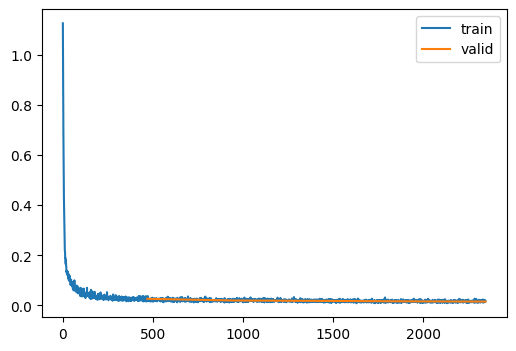

In [21]:
# Train the model for the specified number of epochs
# This calls the training loop which:
# 1. Iterates through all batches in the training data
# 2. For each batch, runs all callbacks (including our DDPMCB)
# 3. Computes loss and updates model weights
# 4. Displays progress and loss curves
learn.fit(epochs)

**What happens during training?**

For each batch:

1. **Data Loading**: Load a batch of 128 images

2. **DDPMCB.before_batch**: 
   - Generate random noise ε
   - Pick random timesteps t for each image
   - Create noisy images: `xₜ = √(ᾱₜ)*x₀ + √(1-ᾱₜ)*ε`

3. **Forward Pass**: 
   - Model receives (noisy_image, timestep)
   - Model predicts the noise: `ε_pred = model(xₜ, t)`

4. **Loss Calculation**: 
   - `loss = MSE(ε_pred, ε)`
   - How different is the predicted noise from the actual noise?

5. **Backward Pass**: 
   - Compute gradients of loss with respect to model weights

6. **Optimizer Step**: 
   - Update weights to reduce the loss

**Expected behavior:**
- Loss should decrease over time
- The model is learning to predict noise at various timesteps

# How DDPM Training Works: Tracing Through the fast.ai Learner + Callback System

## Overview

This document traces exactly how `learn.fit(epochs)` trains a DDPM noise-prediction model, following every line of the actual fast.ai `Learner` source code and the `DDPMCB` callback.

---

## What happens when you call `learn.fit(epochs)`

From the `Learner.fit` method:

```python
def fit(self, n_epochs=1, train=True, valid=True, cbs=None, lr=None):
    self.n_epochs = n_epochs
    self.epochs = range(n_epochs)
    if lr is None: lr = self.lr          # lr = 4e-3
    if self.opt_func: self.opt = self.opt_func(self.model.parameters(), lr)  # creates Adam optimizer
    self._fit(train, valid)
```

This calls `self._fit(train=True, valid=True)`, which is decorated with `@with_cbs('fit')`:

```python
@with_cbs('fit')
def _fit(self, train, valid):
    for self.epoch in self.epochs:
        if train: self.one_epoch(True)
        if valid: torch.no_grad()(self.one_epoch)(False)
```

The `@with_cbs('fit')` decorator means: call `before_fit` on all callbacks first, then run the function, then call `after_fit`. This is where `DeviceCB.before_fit` moves the model to GPU, `ProgressCB` sets up the progress bar, etc.

Then for each epoch, `self.one_epoch(True)` is called:

```python
def one_epoch(self, training):
    self.model.train(training)                                # set model to train mode
    self.dl = self.dls.train if training else self.dls.valid  # pick the dataloader
    self._one_epoch()
```

And `_one_epoch` is again decorated:

```python
@with_cbs('epoch')
def _one_epoch(self):
    for self.iter, self.batch in enumerate(self.dl):
        self._one_batch()
```

So for each batch, `self.batch` is set to whatever the dataloader yields — in our case, just a tuple of clean images like `(x0,)` — and then `_one_batch()` runs.

---

## The Critical Part: `_one_batch()`

```python
@with_cbs('batch')
def _one_batch(self):
    self.predict()
    self.callback('after_predict')
    self.get_loss()
    self.callback('after_loss')
    if self.training:
        self.backward()
        self.callback('after_backward')
        self.step()
        self.callback('after_step')
        self.zero_grad()
```

The `@with_cbs('batch')` decorator calls `before_batch` on all callbacks **before** the body runs. Now let's trace each line.

---

### Step 1: `before_batch` callbacks fire (from the decorator)

Callbacks run sorted by `order`. `DeviceCB` has default `order=0`, and `DDPMCB` has `order = DeviceCB.order + 1 = 1`. So:

**First — `DeviceCB.before_batch` runs:**

```python
def before_batch(self, learn):
    learn.batch = to_device(learn.batch, device=self.device)
```

Moves the clean images to GPU. Now `learn.batch = (x0_on_gpu,)`.

**Second — `DDPMCB.before_batch` runs:**

```python
def before_batch(self, learn):
    device = learn.batch[0].device
    ε = torch.randn(learn.batch[0].shape, device=device)
    x0 = learn.batch[0]
    n = x0.shape[0]
    t = torch.randint(0, self.n_steps, (n,), device=device, dtype=torch.long)
    ᾱ_t = self.ᾱ[t].reshape(-1, 1, 1, 1).to(device)
    xt = ᾱ_t.sqrt()*x0 + (1-ᾱ_t).sqrt()*ε
    learn.batch = ((xt, t), ε)
```

This **completely replaces** `learn.batch`. Before: `(x0,)`. After: `((xt, t), ε)`.

So now:

- `learn.batch[0]` = `(xt, t)` — the inputs (noisy image + timestep)
- `learn.batch[1]` = `ε` — the target (actual noise that was added)

---

### Step 2: `self.predict()`

Now here's the crucial mechanism. `Learner` doesn't define `predict` as a regular method. Look at `__getattr__`:

```python
def __getattr__(self, name):
    if name in ('predict','get_loss','backward','step','zero_grad'):
        return partial(self.callback, name)
    raise AttributeError(name)
```

So `self.predict()` becomes `self.callback('predict')`, which calls `run_cbs(self.cbs, 'predict', self)`. This finds `DDPMCB.predict` (inherited from `TrainCB`, but overridden):

```python
# TrainCB base version:
def predict(self, learn): learn.preds = learn.model(*learn.batch[:self.n_inp])

# DDPMCB override:
def predict(self, learn): learn.preds = learn.model(*learn.batch[0]).sample
```

DDPMCB overrides it because `learn.batch[0]` is the tuple `(xt, t)`, and `*learn.batch[0]` unpacks it:

```python
learn.preds = learn.model(xt, t).sample
# UNet outputs a UNet2DOutput dataclass; .sample extracts the tensor
# Shape: (batch_size, 1, 32, 32) — same shape as the noise ε
```

---

### Step 3: `self.get_loss()`

Same `__getattr__` mechanism — becomes `self.callback('get_loss')`. DDPMCB doesn't override `get_loss`, so the **parent `TrainCB.get_loss`** runs:

```python
def get_loss(self, learn):
    learn.loss = learn.loss_func(learn.preds, *learn.batch[self.n_inp:])
```

`self.n_inp` defaults to `1` in `TrainCB.__init__`. So `learn.batch[1:]` is `(ε,)`, and `*learn.batch[1:]` unpacks to just `ε`. This becomes:

```python
learn.loss = nn.MSELoss()(model_output, ε)
```

**This is the line that makes the model learn to predict noise.** The loss measures how far the model's output is from the actual noise that was added.

---

### Step 4: `self.backward()` → `TrainCB.backward`

```python
def backward(self, learn): learn.loss.backward()
```

Backpropagates gradients through the UNet.

---

### Step 5: `self.step()` → `TrainCB.step`

```python
def step(self, learn): learn.opt.step()
```

Adam updates all UNet parameters to reduce the MSE.

---

### Step 6: `self.zero_grad()` → `TrainCB.zero_grad`

```python
def zero_grad(self, learn): learn.opt.zero_grad()
```

Resets gradients for the next batch.

---

## Summary: Data Flow Through One Batch

```
DataLoader yields (x0,)
        │
   DeviceCB.before_batch  →  moves to GPU
        │
   DDPMCB.before_batch    →  replaces with ((xt, t), ε)
        │
   DDPMCB.predict         →  preds = model(xt, t).sample
        │
   TrainCB.get_loss       →  loss = MSELoss(preds, ε)
        │
   TrainCB.backward       →  loss.backward()
        │
   TrainCB.step           →  opt.step()
        │
   TrainCB.zero_grad      →  opt.zero_grad()
```

---

## Key Insight: The `__getattr__` Trick

The `Learner` class itself has **no** `predict`, `get_loss`, `backward`, `step`, or `zero_grad` methods. When `_one_batch` calls `self.predict()`, Python can't find it as a regular attribute, so it falls through to `__getattr__`:

```python
def __getattr__(self, name):
    if name in ('predict','get_loss','backward','step','zero_grad'):
        return partial(self.callback, name)
    raise AttributeError(name)
```

This returns `partial(self.callback, 'predict')`, which when called executes `run_cbs(self.cbs, 'predict', self)` — running the `predict` method on whichever callback defines it (in our case, `DDPMCB`).

This means the callbacks fully control every step of training. The `Learner` class itself is just an orchestrator that calls callbacks in the right order. It has no idea it's training a diffusion model.

# How `__getattr__` Dispatches to Callbacks in fast.ai's Learner

## Step 1: `self.predict()` is called inside `_one_batch`

Python first looks for `predict` as a normal attribute or method on the `Learner` instance and its class. It doesn't find one — `Learner` never defines `def predict(self)`. When normal lookup fails, Python calls `__getattr__` as a fallback:

```python
def __getattr__(self, name):   # name = 'predict'
    if name in ('predict','get_loss','backward','step','zero_grad'):
        return partial(self.callback, name)
    raise AttributeError(name)
```

`'predict'` is in that tuple, so it returns:

```python
partial(self.callback, 'predict')
```

This is a **callable object** — a partially applied function. It's equivalent to a function that, when called with no arguments, executes `self.callback('predict')`.

---

## Step 2: The returned partial gets called immediately

Back in `_one_batch`, the code is `self.predict()`. The `self.predict` part returned the partial, and the `()` immediately calls it. So this executes:

```python
self.callback('predict')
```

---

## Step 3: `self.callback` calls `run_cbs`

```python
def callback(self, method_nm): run_cbs(self.cbs, method_nm, self)
```

So this becomes:

```python
run_cbs(self.cbs, 'predict', self)
```

---

## Step 4: `run_cbs` iterates through all callbacks

```python
def run_cbs(cbs, method_nm, learn=None):
    for cb in sorted(cbs, key=attrgetter('order')):
        method = getattr(cb, method_nm, None)
        if method is not None: method(learn)
```

This loops through all callbacks sorted by `order`, and for each one, tries `getattr(cb, 'predict', None)`. Let's check each callback in our setup:

| Callback | Has `predict`? | What happens |
|---|---|---|
| `DDPMCB` (inherits from `TrainCB`) | **Yes** — overrides it | `method = DDPMCB.predict` |
| `DeviceCB` | No | `method = None`, skipped |
| `ProgressCB` | No | `method = None`, skipped |
| `MetricsCB` | No | `method = None`, skipped |
| `BatchSchedCB` | No | `method = None`, skipped |

So only `DDPMCB.predict` is found, and `run_cbs` calls it:

```python
method(learn)
# which is:
DDPMCB.predict(learn)
```

Which executes:

```python
def predict(self, learn):
    learn.preds = learn.model(*learn.batch[0]).sample
```

---

## The Full Chain in One Line

```
self.predict()
  → __getattr__('predict') returns partial(self.callback, 'predict')
    → calling it executes self.callback('predict')
      → run_cbs(self.cbs, 'predict', self)
        → finds DDPMCB.predict via getattr(cb, 'predict')
          → DDPMCB.predict(learn) executes
            → learn.preds = learn.model(xt, t).sample
```

---

## Why This Design Exists

The `Learner` doesn't need to know *anything* about how prediction, loss computation, or optimization work. Any callback can define or override any of these steps. In our case, `DDPMCB` overrides `predict` to unpack the noisy image and timestep, while inheriting `get_loss`, `backward`, `step`, and `zero_grad` from its parent `TrainCB`.

### 🎮 Interactive: Who Calls What? Learner + DDPMCB Dispatch

A clickable call-stack trace of one training batch: `fit -> one_epoch -> one_batch -> callback('before_batch') -> DDPMCB.before_batch -> DDPMCB.predict -> TrainCB.get_loss -> backward/step`. Badges show whose code runs at each frame — and reveal that DDPM added only ~30 purple lines to an otherwise untouched training loop.

In [ ]:
show_viz("interactive_viz/callback_dispatch_flow.html", height="780px")

# Two Different `sample`s in DDPM Code: Dataclass Attribute vs Generation Method

## The `.sample` in `predict` — A Dataclass Attribute

```python
def predict(self, learn): learn.preds = learn.model(*learn.batch[0]).sample
```

Here, `learn.model(xt, t)` calls the HuggingFace `UNet2DModel`. This model doesn't return a raw tensor. It returns a `UNet2DOutput` dataclass that looks like this:

```python
@dataclass
class UNet2DOutput:
    sample: torch.Tensor   # ← this is just a field name
```

So `.sample` here is just **accessing a named field** on the returned dataclass — like doing `person.name` on a `Person` object. It extracts the output tensor. It is **not** a method call (no parentheses).

---

## The `sample` Method in DDPMCB — A Completely Separate Thing

```python
@torch.no_grad()
def sample(self, model, sz):
    # ... reverse diffusion loop to generate images from noise
```

This is a **method** you call manually **after training** to generate new images. You'd call it like:

```python
samples = ddpm_cb.sample(model, (16, 1, 32, 32))
```

It requires two arguments (`model` and `sz`), runs the full reverse diffusion loop for 1000 steps, and returns a list of progressively denoised images.

---

## Side-by-Side Comparison

| | `.sample` in `predict` | `sample()` method |
|---|---|---|
| **What it is** | A field on `UNet2DOutput` dataclass | A method on `DDPMCB` class |
| **Syntax** | `.sample` (no parentheses — attribute access) | `.sample(model, sz)` (parentheses — method call) |
| **Called when** | Every training batch, inside the training loop | Manually by you, after training is done |
| **Returns** | A single tensor of shape `(batch, 1, 32, 32)` | A list of 1000 tensors (one per denoising step) |
| **Purpose** | Extract the UNet's prediction | Generate new images via reverse diffusion |

They have no connection to each other. The name collision is just coincidental — HuggingFace chose `sample` as their output field name, and the fast.ai course chose `sample` as the name for the generation method.

### Saving and Loading the Model

After training, we save the model so we don't have to retrain it later.

In [ ]:
# Create a directory to store saved models
# Path() creates a path object for easy manipulation
# mkdir() creates the directory
# exist_ok=True means don't raise an error if it already exists
mdl_path = Path('models')
mdl_path.mkdir(exist_ok=True)

In [ ]:
# Save the trained model to a file
# torch.save() serializes the model to disk
# mdl_path/'fashion_ddpm.pkl' creates the full file path
torch.save(learn.model, mdl_path/'fashion_ddpm.pkl')

In [26]:
# Load the model back from the file
# This is useful if you restart the notebook and want to skip training
learn.model = torch.load(mdl_path/'fashion_ddpm.pkl', weights_only=False)

**What does the code above do?**

1. **`Path('models').mkdir(exist_ok=True)`**: Creates a `models` folder if it doesn't exist.

2. **`torch.save(learn.model, path)`**: Saves the entire model (architecture + weights) to a file.

3. **`torch.load(path)`**: Loads the saved model back into memory.

**Why save models?**
- Training takes time (and GPU resources)
- Once trained, you can reuse the model without retraining
- You can share trained models with others

---

## Section 6: Inference (Generating New Images)

Now the exciting part - using our trained model to generate new images!

The generation process (also called "sampling" or "inference") works as follows:

1. Start with pure random noise
2. Run through 1000 denoising steps
3. At each step, the model predicts and removes some noise
4. After all steps, we have a clean generated image!

In [27]:
# Set seed for reproducible results
set_seed(42)

# Generate samples using our DDPM callback's sample method
# Parameters:
# - learn.model: Our trained U-Net
# - (16, 1, 32, 32): Shape of images to generate
#   - 16: Generate 16 images
#   - 1: 1 color channel (grayscale)
#   - 32, 32: Image dimensions
samples = ddpm_cb.sample(learn.model, (16, 1, 32, 32))

# samples is a list with one entry per timestep (1000 total)
# This lets us visualize the denoising process
len(samples)

1000

**What does the code above do?**

1. **`set_seed(42)`**: Sets random seed so we get the same "random" noise each time.

2. **`ddpm_cb.sample(learn.model, (16, 1, 32, 32))`**: Generates 16 new images:
   - Starts with random noise of shape (16, 1, 32, 32)
   - Runs 1000 denoising steps
   - Returns a list of 1000 tensors (the image at each step)

3. **`len(samples)` returns 1000**: We have saved the state at every timestep so we can visualize the denoising process.

**The sampling process visualized:**
```
samples[0]   → Image at t=999 (almost pure noise)
samples[500] → Image at t=499 (halfway denoised)
samples[999] → Image at t=0 (final clean image)
```

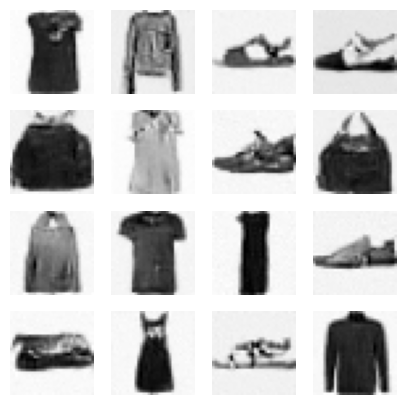

In [28]:
# Display the final generated images
# samples[-1] gets the last element (the fully denoised images)
# We negate (-) because our images are inverted (white background in data)
# figsize=(5,5) sets the display size
show_images(-samples[-1], figsize=(5, 5))

**What does the code above do?**

1. **`samples[-1]`**: Gets the final (fully denoised) images. In Python, `[-1]` means the last element.

2. **`-samples[-1]`**: Negates the pixel values. This is because Fashion MNIST has inverted colors (white background), and negating makes them look better.

3. **`show_images(..., figsize=(5,5))`**: Displays the 16 generated images in a grid.

**What you should see:**
Generated images that look like clothing items from Fashion MNIST! They won't be perfect, but you should recognize:
- T-shirts
- Pants/trousers
- Shoes
- Bags
- etc.

These are completely new images that didn't exist in the training data - the model has learned to generate realistic clothing images!

### Visualizing the Sampling Process

Let's create an animation to see how the image emerges from noise!

In [29]:
# Switch to interactive matplotlib mode for animations
%matplotlib auto

# Import animation tools
import matplotlib.animation as animation  # For creating animations
from IPython.display import display, HTML  # For displaying in Jupyter

# Create a figure and axis for the animation
# figsize=(3,3) creates a 3x3 inch figure
fig, ax = plt.subplots(figsize=(3, 3))

def _show_i(i):
    """
    Helper function to show the image at timestep i.
    
    Parameters:
    -----------
    i : int
        The timestep index (in our samples list)
        
    Returns:
    --------
    list of images for the animation
    """
    # samples[i][9] gets the 10th image (index 9) at timestep i
    # We negate for better visualization
    # animated=True tells matplotlib this is for animation
    return show_image(-samples[i][9], ax=ax, animated=True).get_images()

# Create list of timestep indices to show
# L is a fastcore list with .map and + operations
# We skip early steps (lots of noise, not interesting) and focus on steps 800-1000
# L.range(800, 990, 5): steps 800, 805, 810, ..., 985 (every 5th step)
# L.range(990, 1000): steps 990, 991, 992, ..., 999 (every step near the end)
# [999]*10: repeat final image 10 times (pause at the end)
r = L.range(800, 990, 5) + L.range(990, 1000) + [999] * 10
"""
L.range(800, 990, 5)
# [800, 805, 810, 815, 820, ..., 980, 985]
# Every 5th step from 800 to 989
# Total: 38 frames

L.range(990, 1000)
# [990, 991, 992, 993, 994, 995, 996, 997, 998, 999]
# Every step from 990 to 999 (more detail at the end)
# Total: 10 frames

[999] * 10
# [999, 999, 999, 999, 999, 999, 999, 999, 999, 999]
# Repeat final frame 10 times (pause at end)
# Total: 10 frames

# Combined:
r = [800, 805, 810, ..., 985, 990, 991, 992, ..., 999, 999, 999, ...]
# Total: 38 + 10 + 10 = 58 frames
"""

# Apply _show_i to each timestep to create animation frames
# .map() applies a function to each element in the list
ims = r.map(_show_i)

# Create the animation
# - fig: the figure object
# - ims: list of frames
# - interval=50: 50ms between frames (20 fps)
# - blit=True: only redraw changed parts (faster)
# - repeat_delay=3000: 3 second pause before looping
animate = animation.ArtistAnimation(fig, ims, interval=50, blit=True, repeat_delay=3000)

# Display the animation as an HTML5 video
display(HTML(animate.to_html5_video()))

Using matplotlib backend: <object object at 0x7fbb3c1430e0>


## Understanding the Denoising Animation Code

---

### What `r.map(_show_i)` Does

`r` is a list of timestep indices. `.map(_show_i)` calls `_show_i(i)` for every value `i` in `r`. So:

```python
ims = [
    _show_i(800),   # frame 1
    _show_i(805),   # frame 2
    _show_i(810),   # frame 3
    ...
    _show_i(999),   # frame 58
]
```

Each call returns one animation frame — a snapshot of the 10th image at that particular timestep.

---

### What `samples` Contains — The Key to Understanding This

Recall from the `sample` function:

```python
preds.append(x_t.cpu())
```

`preds` (called `samples` here) is a list of **1000 tensors**, one per timestep. But remember the loop goes **backwards** from 999 down to 0:

```
samples[0]    →  x_t after denoising step t=999  (still very noisy)
samples[1]    →  x_t after denoising step t=998  (slightly less noisy)
samples[2]    →  x_t after denoising step t=997
...
samples[999]  →  x_t after denoising step t=0    (final clean image)
```

Each `samples[i]` is a tensor of shape `(16, 1, 32, 32)` — all 16 generated images at that stage of denoising.

---

### So What Does `samples[i][9]` Mean?

```python
samples[i]     # the batch of 16 images at denoising stage i
samples[i][9]  # specifically the 10th image (index 9) out of those 16
               # shape: (1, 32, 32) — one single image
```

We are not switching between 16 different images across frames. We are **tracking one single image** (the 10th one) as it gets denoised across timesteps.

---

### The Full Picture of the Animation

So yes — the animation shows the 10th image at timesteps 800, 805, 810, ..., 999. But these are not different images. They are the **same image at different stages of denoising**:

```
Frame 1:  samples[800][9]  →  10th image when still 80% through denoising (quite noisy)
Frame 2:  samples[805][9]  →  same image, 5 steps later, slightly cleaner
Frame 3:  samples[810][9]  →  same image, 5 more steps later
...
Frame 38: samples[985][9]  →  same image, nearly clean
Frame 39: samples[990][9]  →  same image, very close to final
...
Frame 48: samples[999][9]  →  same image, fully denoised — the final result
Frame 49: samples[999][9]  →  same final image again (pause)
...
Frame 58: samples[999][9]  →  same final image again (pause)
```

You are watching **one image being born** — starting from noise and gradually resolving into a recognizable Fashion-MNIST item.

---

### Why Start at Step 800 and Not Step 0?

The first 800 steps are skipped because they are visually uninteresting — the image is almost entirely noise and you cannot see any meaningful structure emerging yet. Starting at step 800 means the image already has some faint structure, and the animation captures the most visually compelling part of the denoising process.

The last 10 steps (990–999) are shown one by one rather than every 5th step, because that is where the fine details — textures, edges, sharp features — emerge most dramatically.

---

### Why Negate? `show_image(-samples[i][9], ...)`

The pixel values in `samples` range from roughly $[-1, 1]$ because the training data was normalized to that range. Negating flips the contrast — making what was dark light and vice versa — which often looks better visually for grayscale Fashion-MNIST images. It is purely a display choice, not mathematically meaningful.

---

### Summary

| Expression | What it refers to |
|---|---|
| `samples` | List of 1000 tensors, one per denoising step, shape `(16, 1, 32, 32)` each |
| `samples[i]` | All 16 generated images at denoising stage `i` |
| `samples[i][9]` | The 10th image specifically, at denoising stage `i`, shape `(1, 32, 32)` |
| `r` | List of 58 stage indices to use as animation frames |
| `r.map(_show_i)` | One animation frame per index in `r`, all showing the same 10th image at different stages |
| The full animation | One image being denoised from noise to a clean output, shown across 58 frames |

**What does the code above do?**

This creates an animation showing how the image emerges from noise:

1. **`%matplotlib auto`**: Enables interactive matplotlib mode for animations.

2. **`fig, ax = plt.subplots(figsize=(3, 3))`**: Creates a figure and axis for plotting.

3. **`_show_i(i)`**: A helper function that displays the image at a given timestep.

4. **`r = L.range(800, 990, 5) + L.range(990, 1000) + [999]*10`**: 
   - We focus on steps 800-1000 because that's where the most visible denoising happens
   - Early steps (0-799) are mostly noise and not interesting to watch
   - Steps are: 800, 805, 810, ..., 985, 990, 991, ..., 999, 999, 999, ... (10 times)

5. **Animation creation**: Combines all frames into an animated video.

**What you should see:**
An animation where:
- It starts as blurry noise
- Gradually, a shape emerges
- Fine details appear
- Final image shows a recognizable clothing item

---

## Notes on the Noise Schedule

You might notice that most of the visible image formation happens in the last 200 steps (800-1000). This is a limitation of the linear noise schedule used for small images.

**Why does this happen?**

The linear schedule was designed for larger images (like 256x256). For small images like 32x32:
- The image gets "too noisy too fast" in the early steps
- Most timesteps are effectively pure noise
- Only the final steps show interesting denoising

**How to fix it?**

The paper "Improved Denoising Diffusion Probabilistic Models" (2021) proposes a **cosine schedule** that works better for small images. This could be a good exercise to try!

---

## Summary

Congratulations! You've just trained your first diffusion model! Let's recap what we learned:

**Key Concepts:**

1. **Diffusion Models** learn to generate images by learning to reverse a noising process.

2. **Forward Process**: Gradually add Gaussian noise to images until they become pure noise.
   - Formula: `xₜ = √(ᾱₜ) * x₀ + √(1-ᾱₜ) * ε`

3. **Reverse Process**: Start from noise and iteratively denoise to generate images.

4. **Training**: The model learns to predict the noise at any given timestep.
   - Input: (noisy_image, timestep)
   - Output: predicted_noise
   - Loss: MSE between predicted and actual noise

5. **Variance Schedule**: Defines how much noise to add at each timestep.
   - DDPM uses a linear schedule from β_min to β_max

6. **U-Net Architecture**: The neural network that does the noise prediction.
   - Takes in noisy images and timesteps
   - Outputs noise predictions

**What's Next?**

In future notebooks, we'll:
- Build our own U-Net from scratch
- Explore better noise schedules
- Add conditioning (generate specific types of images)
- Scale up to larger, more complex images
- Eventually build towards Stable Diffusion!